In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import seaborn as sns

In [3]:
import chardet

with open('spam.csv', 'rb') as f:
    result = chardet.detect(f.read())
    print(result)

{'encoding': 'Windows-1252', 'confidence': 0.7269493857068697, 'language': ''}


In [4]:
df = pd.read_csv('spam.csv', encoding='Windows-1252')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
drop_cols = [ 'Unnamed: 2','Unnamed: 3','Unnamed: 4']
df =df.drop(columns=drop_cols)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.duplicated().sum()

np.int64(403)

In [9]:
df.drop_duplicates(inplace = True)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.rename(columns={ 'v1' : 'Ham/Spam', 'v2' : 'sms'})

In [12]:
df.columns

Index(['Ham/Spam', 'sms'], dtype='object')

In [13]:
df['Ham/Spam'].value_counts()

Ham/Spam
ham     4516
spam     653
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [15]:
df['Ham/Spam']= encoder.fit_transform(df['Ham/Spam'])

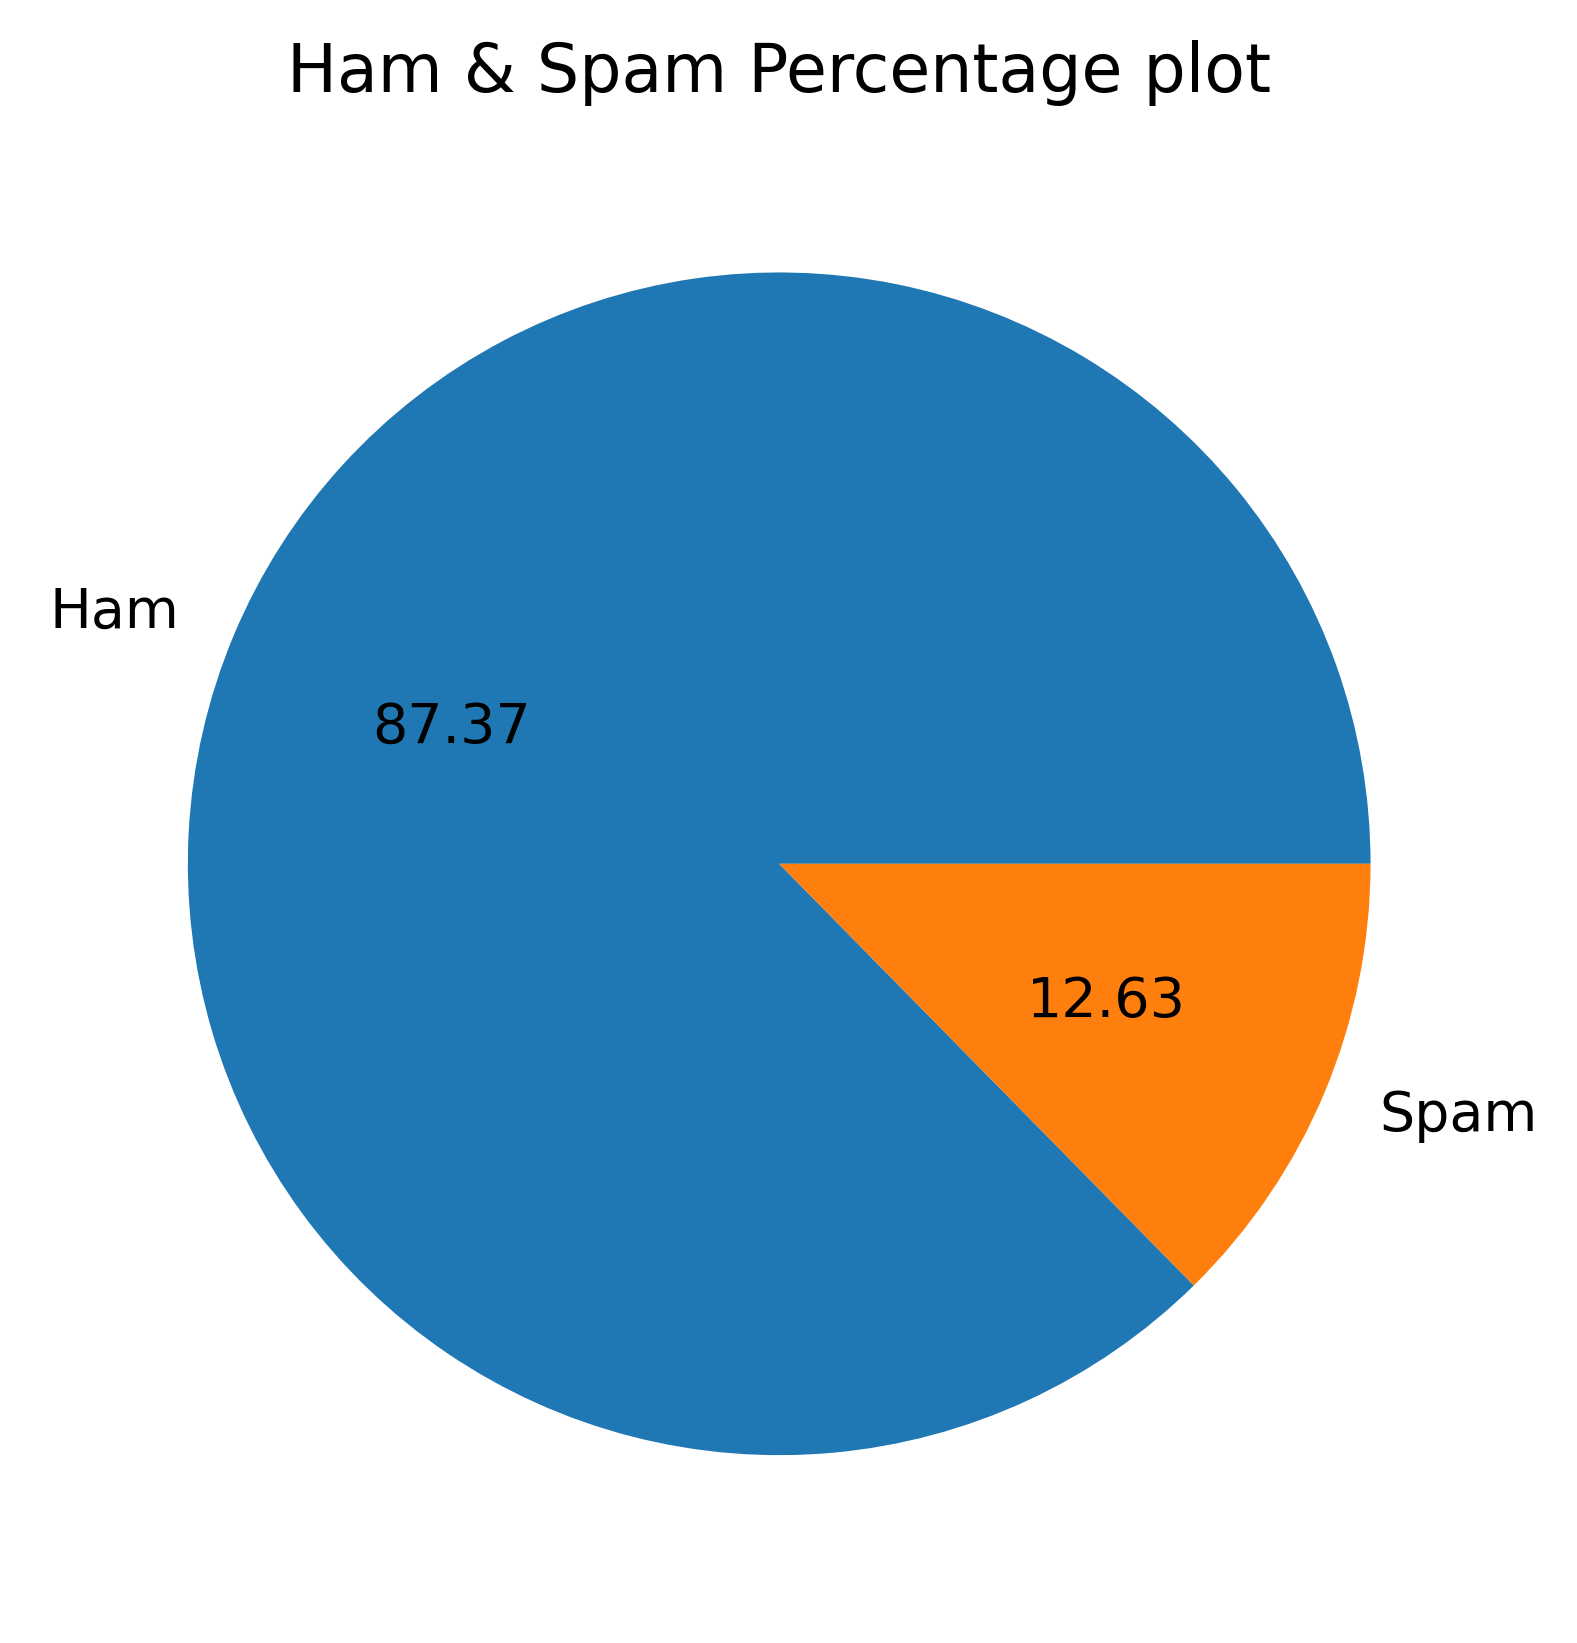

In [16]:
plt.pie(df['Ham/Spam'].value_counts() , labels = ['Ham' , 'Spam'], autopct = '%0.2f')
plt.title('Ham & Spam Percentage plot')
plt.show()

In [17]:
df['nums_sms'] = df['sms'].apply(len)

In [18]:
import nltk

In [19]:
df['num_words'] = df['sms'].apply( lambda x : len(nltk.word_tokenize(x)))

In [20]:
df.head()

,Ham/Spam,sms,nums_sms,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [21]:
df['num_sentence'] = df['sms'].apply( lambda x : len(nltk.sent_tokenize(x)))

In [22]:
df.head()

,Ham/Spam,sms,nums_sms,num_words,num_sentence
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [23]:
df[df['Ham/Spam'] == 0][['nums_sms','num_words','num_sentence']].describe()

,nums_sms,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
df[df['Ham/Spam'] == 1][['nums_sms','num_words','num_sentence']].describe()

,nums_sms,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


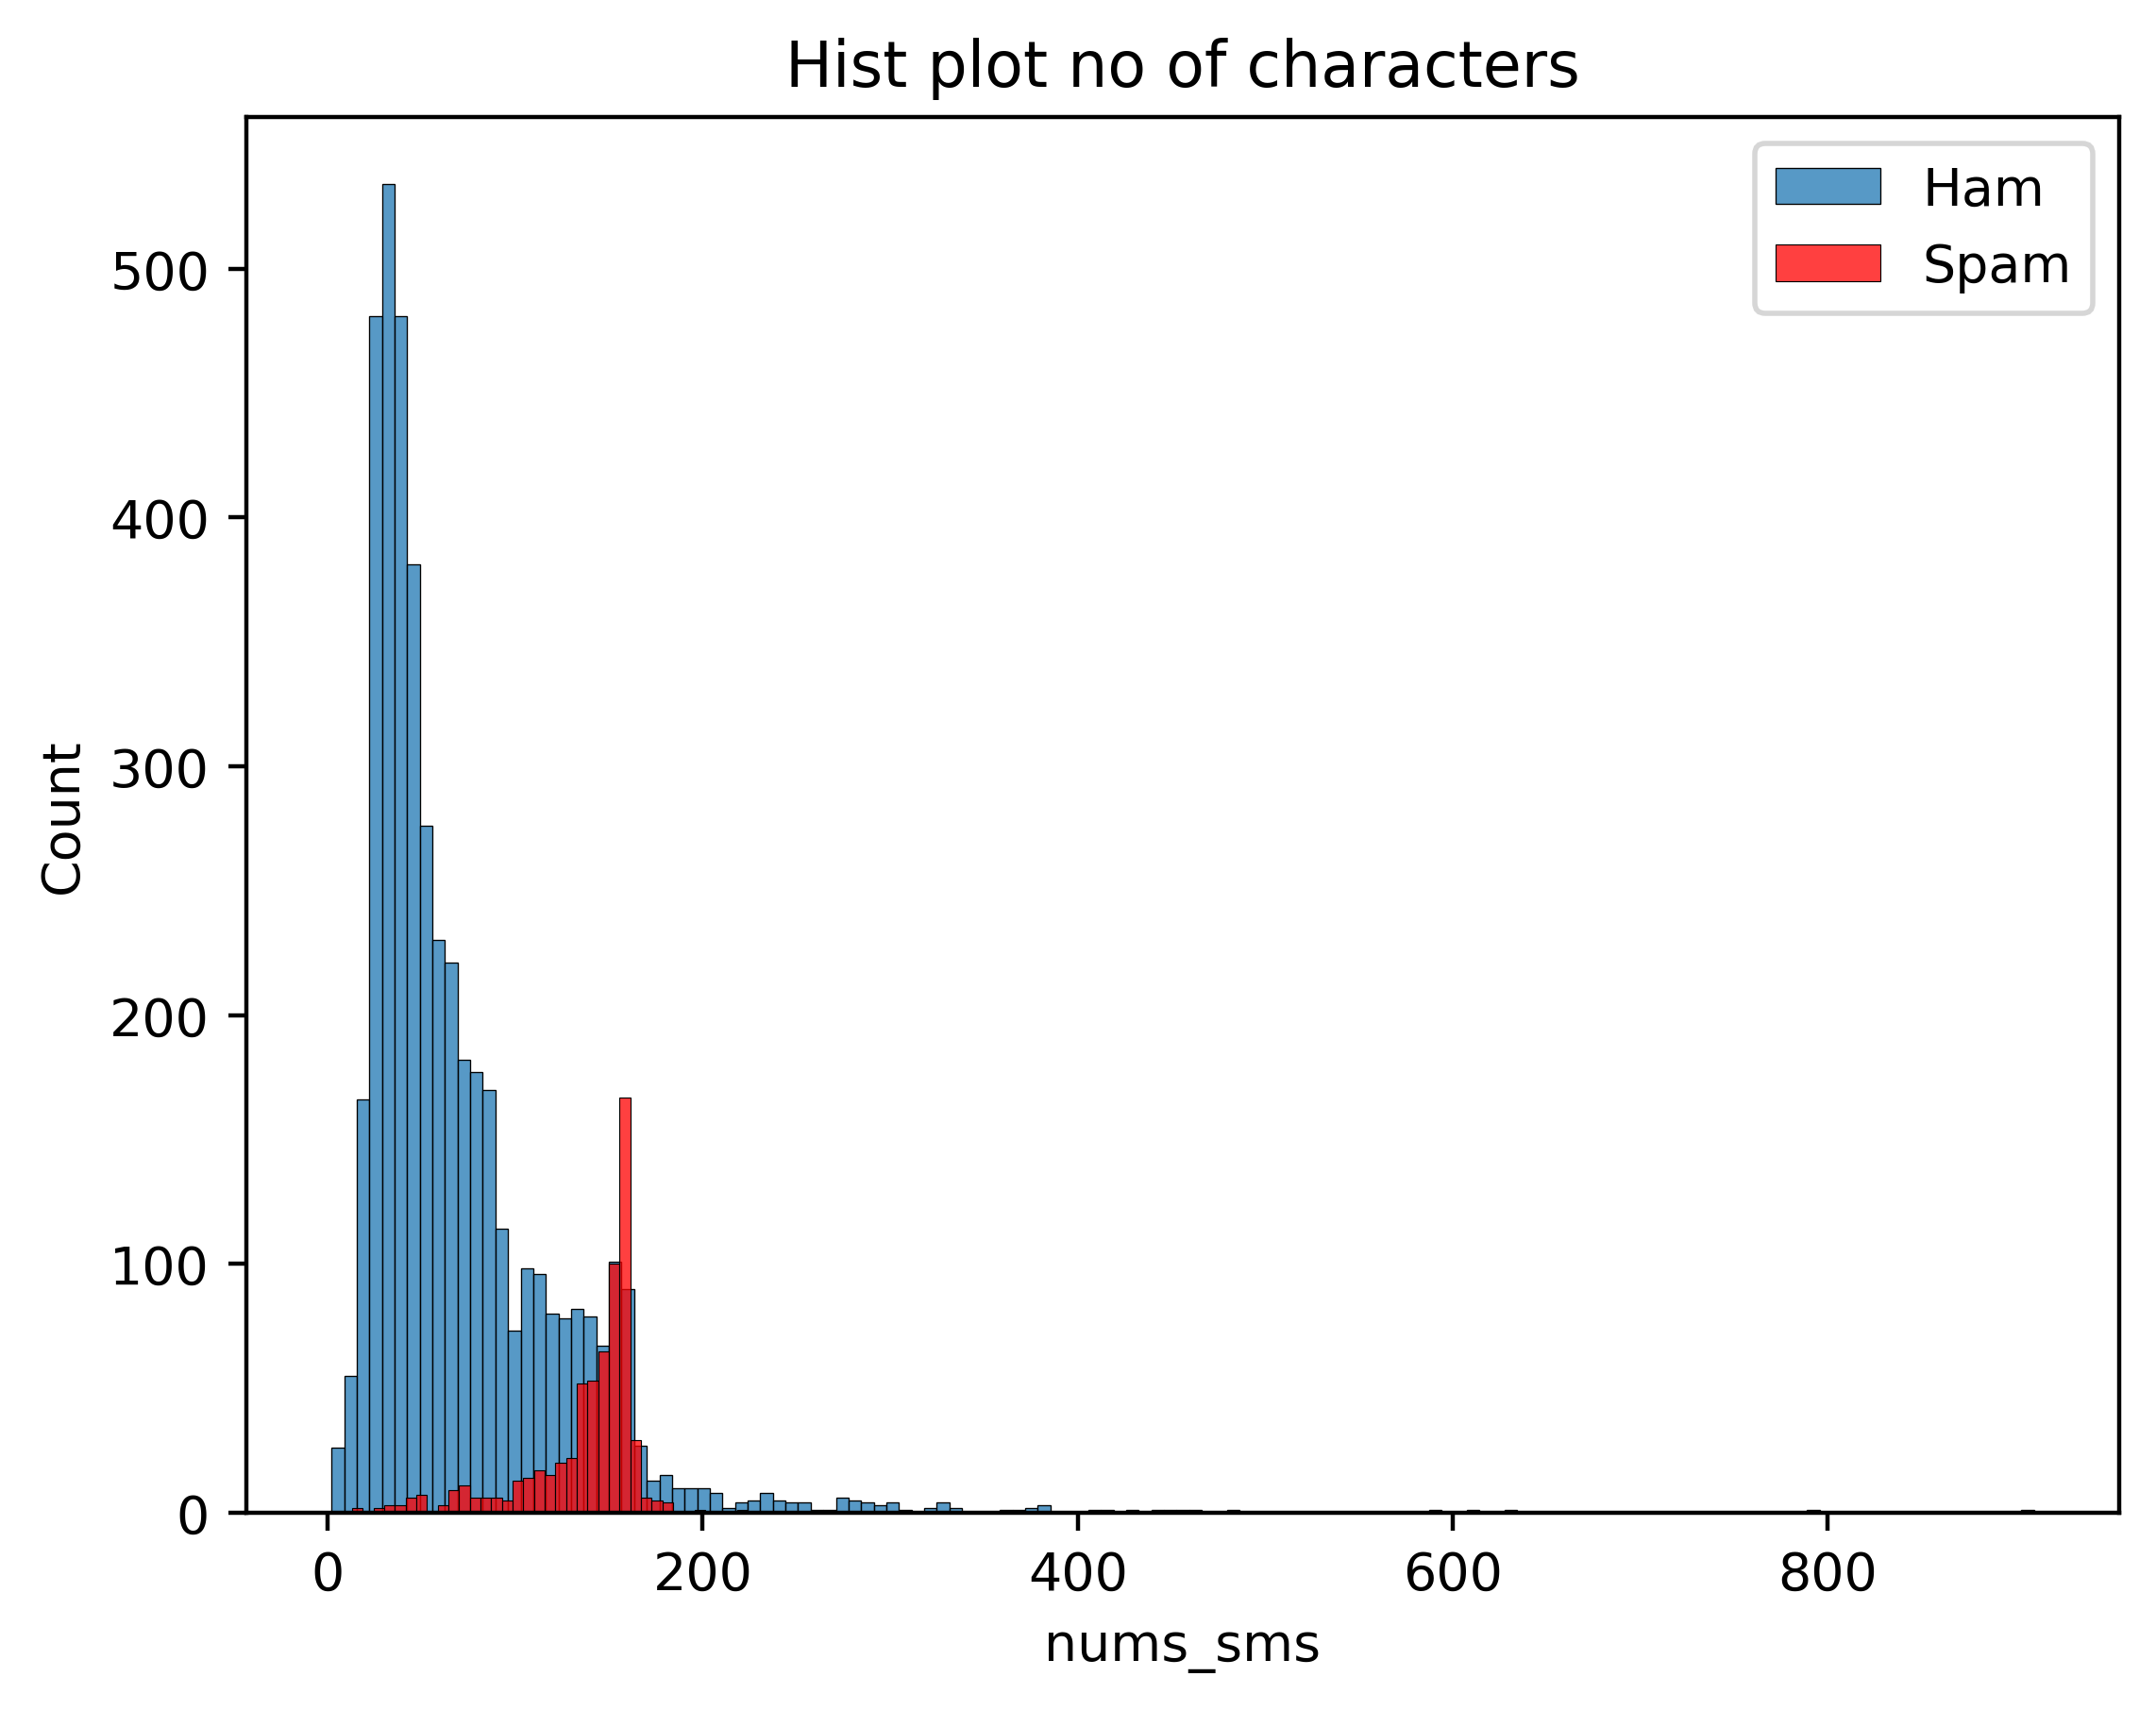

In [25]:
sns.histplot( df[df['Ham/Spam'] == 0]['nums_sms'],label = 'Ham')
sns.histplot( df[df['Ham/Spam'] == 1]['nums_sms'],label = 'Spam', color = 'red')
plt.title('Hist plot no of characters')
plt.legend()
plt.show()

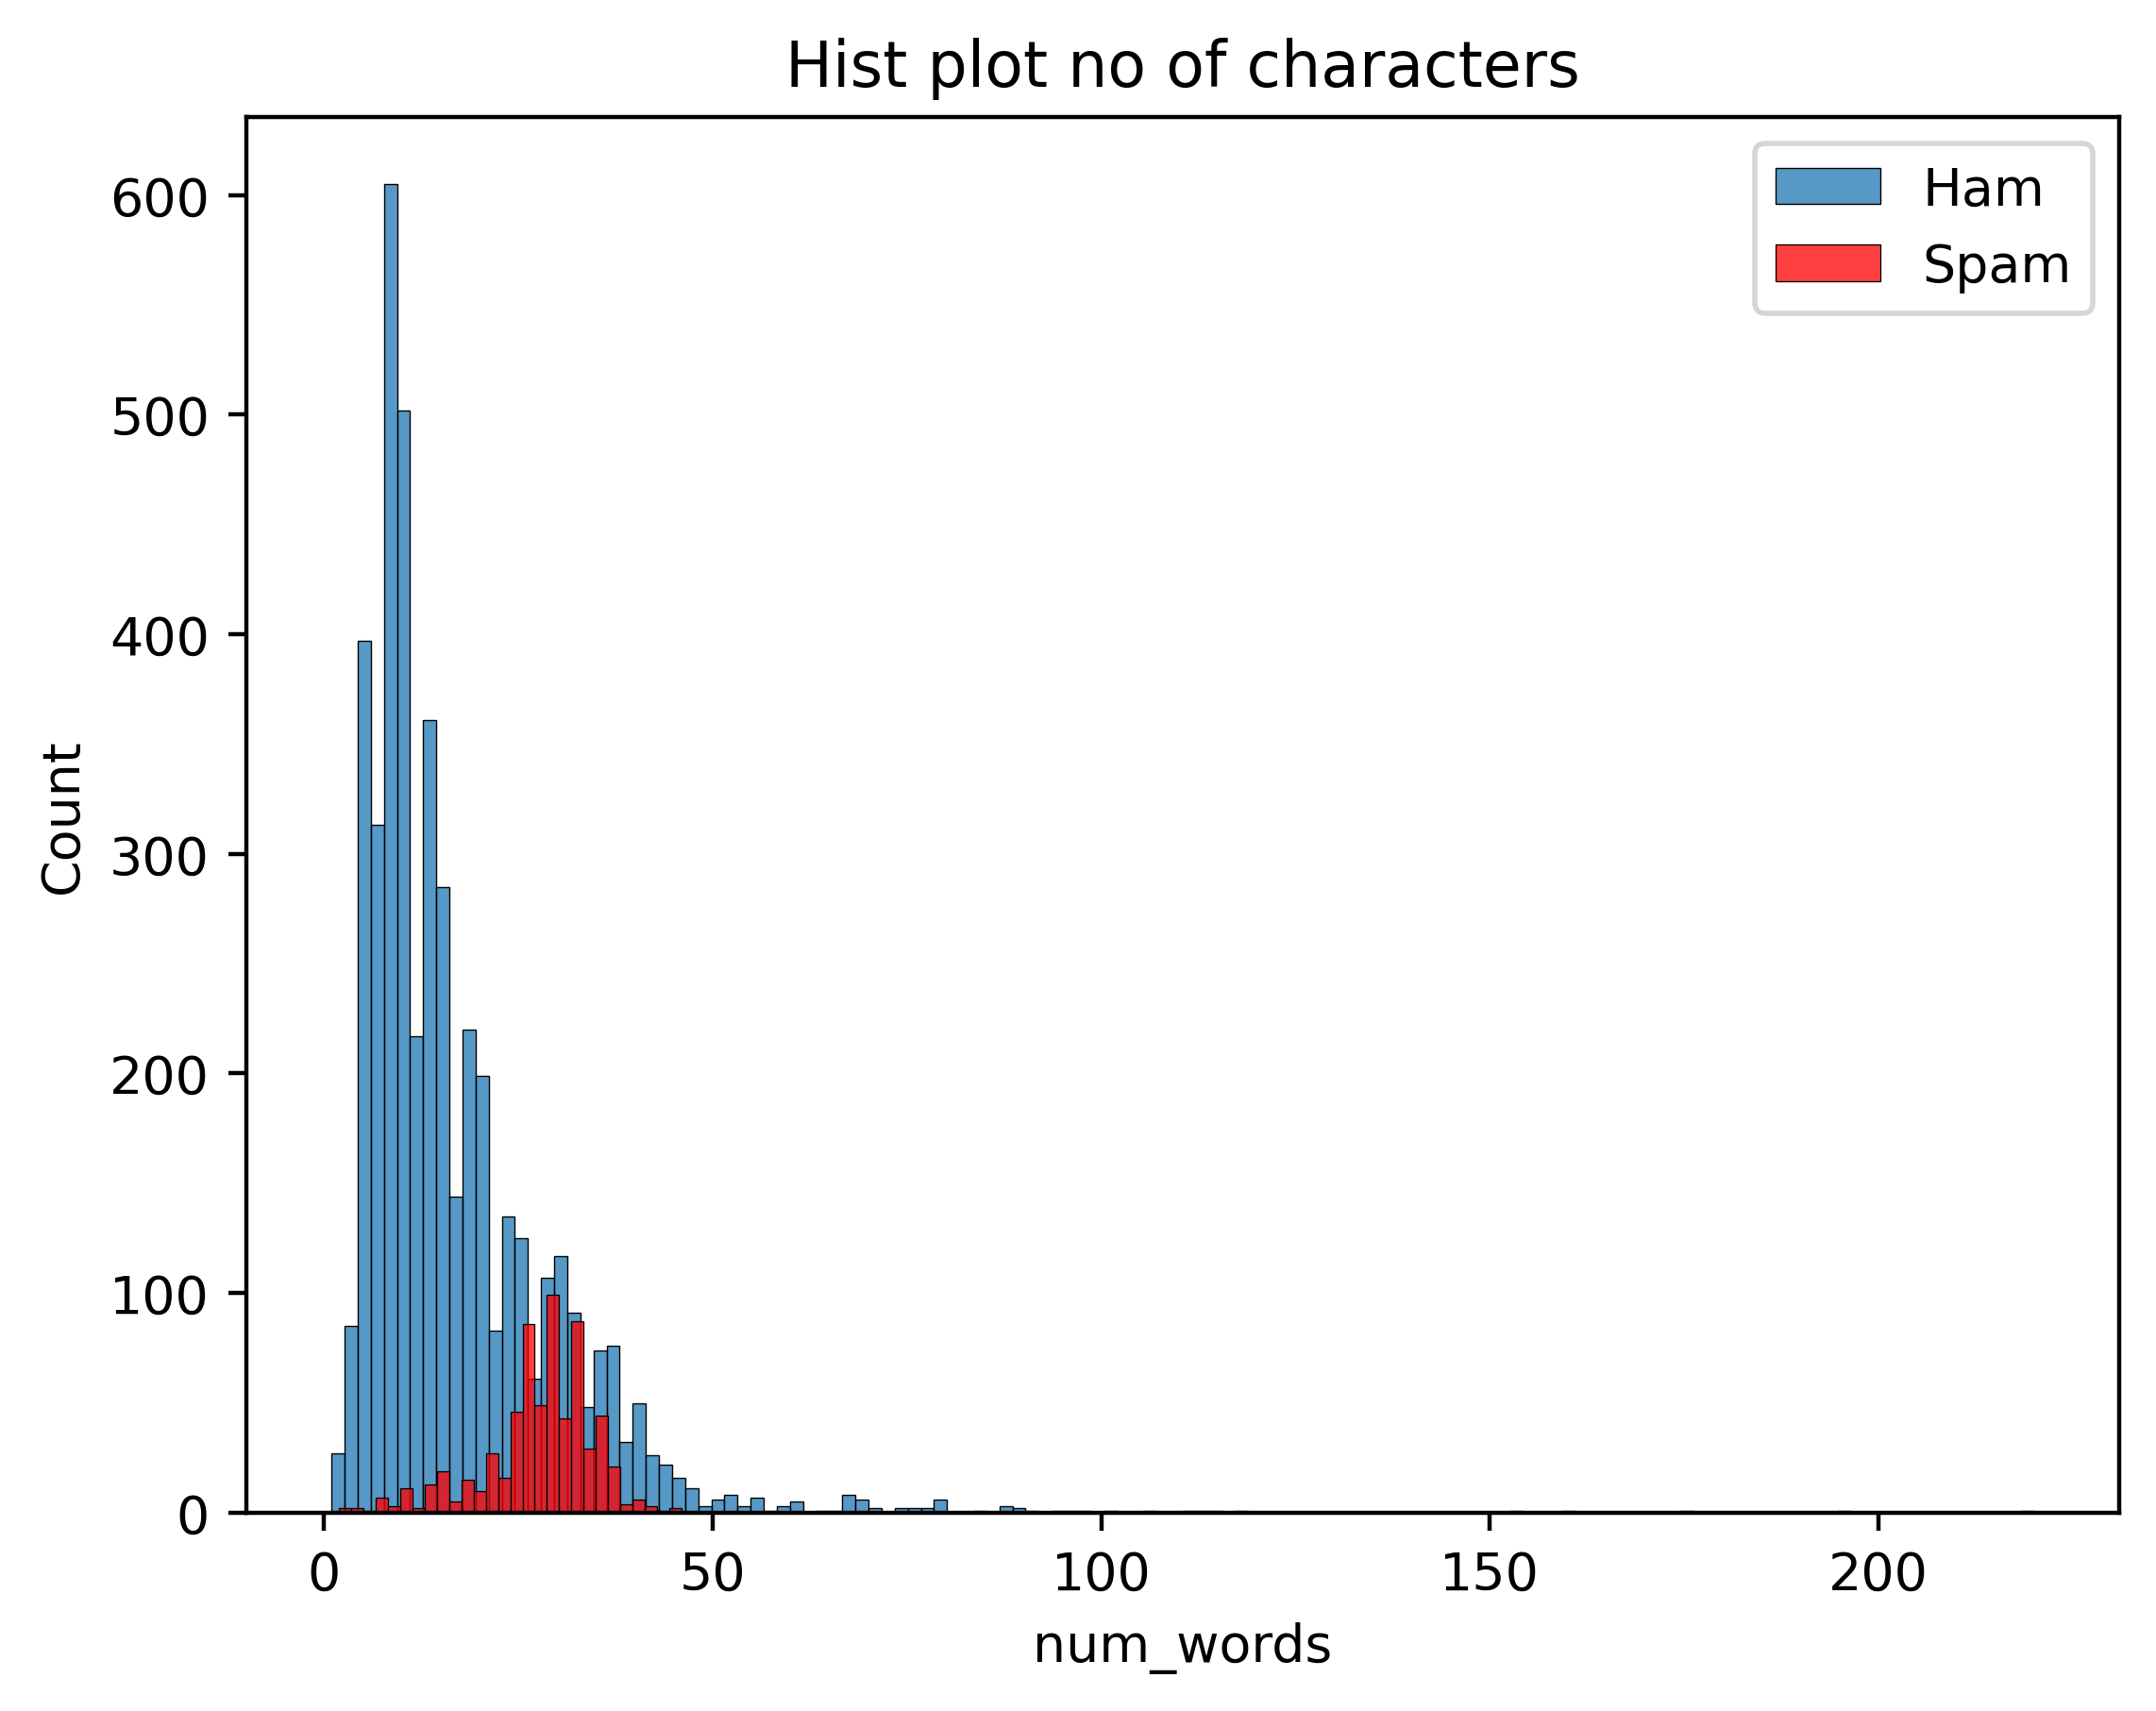

In [26]:
sns.histplot( df[df['Ham/Spam'] == 0]['num_words'],label = 'Ham')
sns.histplot( df[df['Ham/Spam'] == 1]['num_words'],label = 'Spam', color = 'red')
plt.title('Hist plot no of characters')
plt.legend()
plt.show()

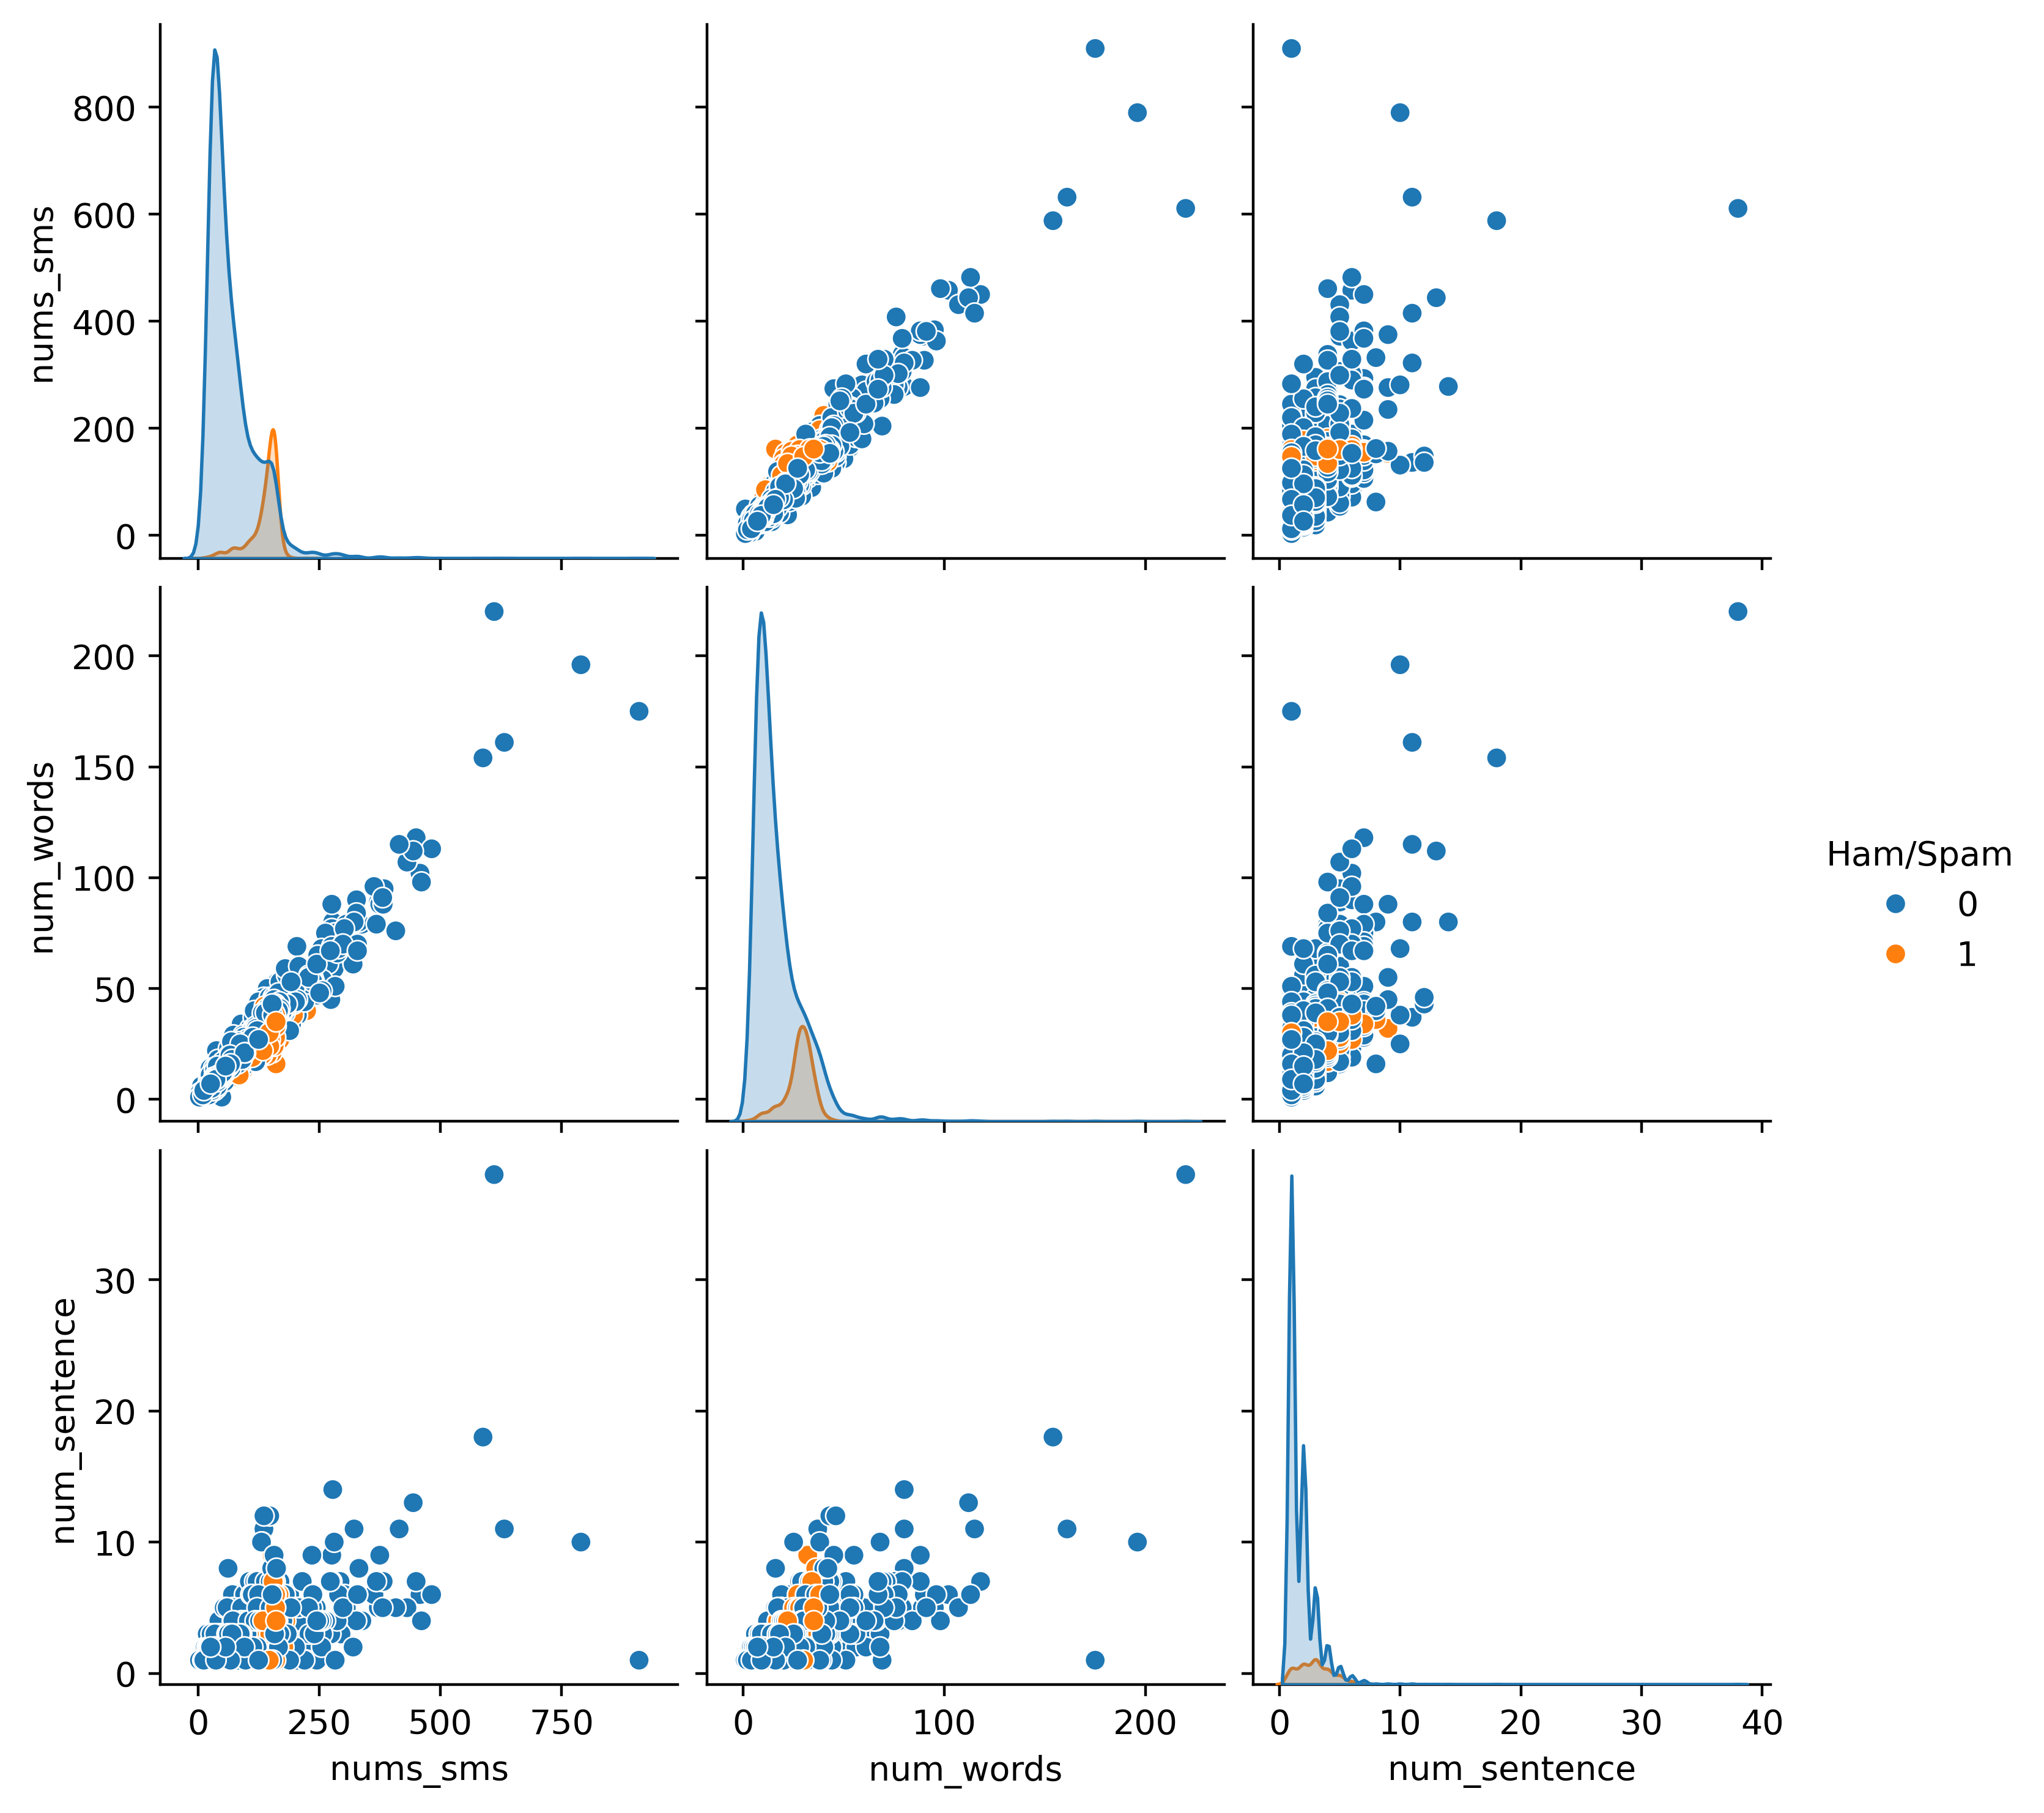

In [27]:
sns.pairplot(df, hue='Ham/Spam')

In [28]:
num_df = df[['Ham/Spam','nums_sms','num_words','num_sentence']]

In [29]:
num_df.corr()

,Ham/Spam,nums_sms,num_words,num_sentence
Ham/Spam,1.000000,0.384717,0.262912,0.263939
nums_sms,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentence,0.263939,0.624139,0.679971,1.000000


<Axes: >

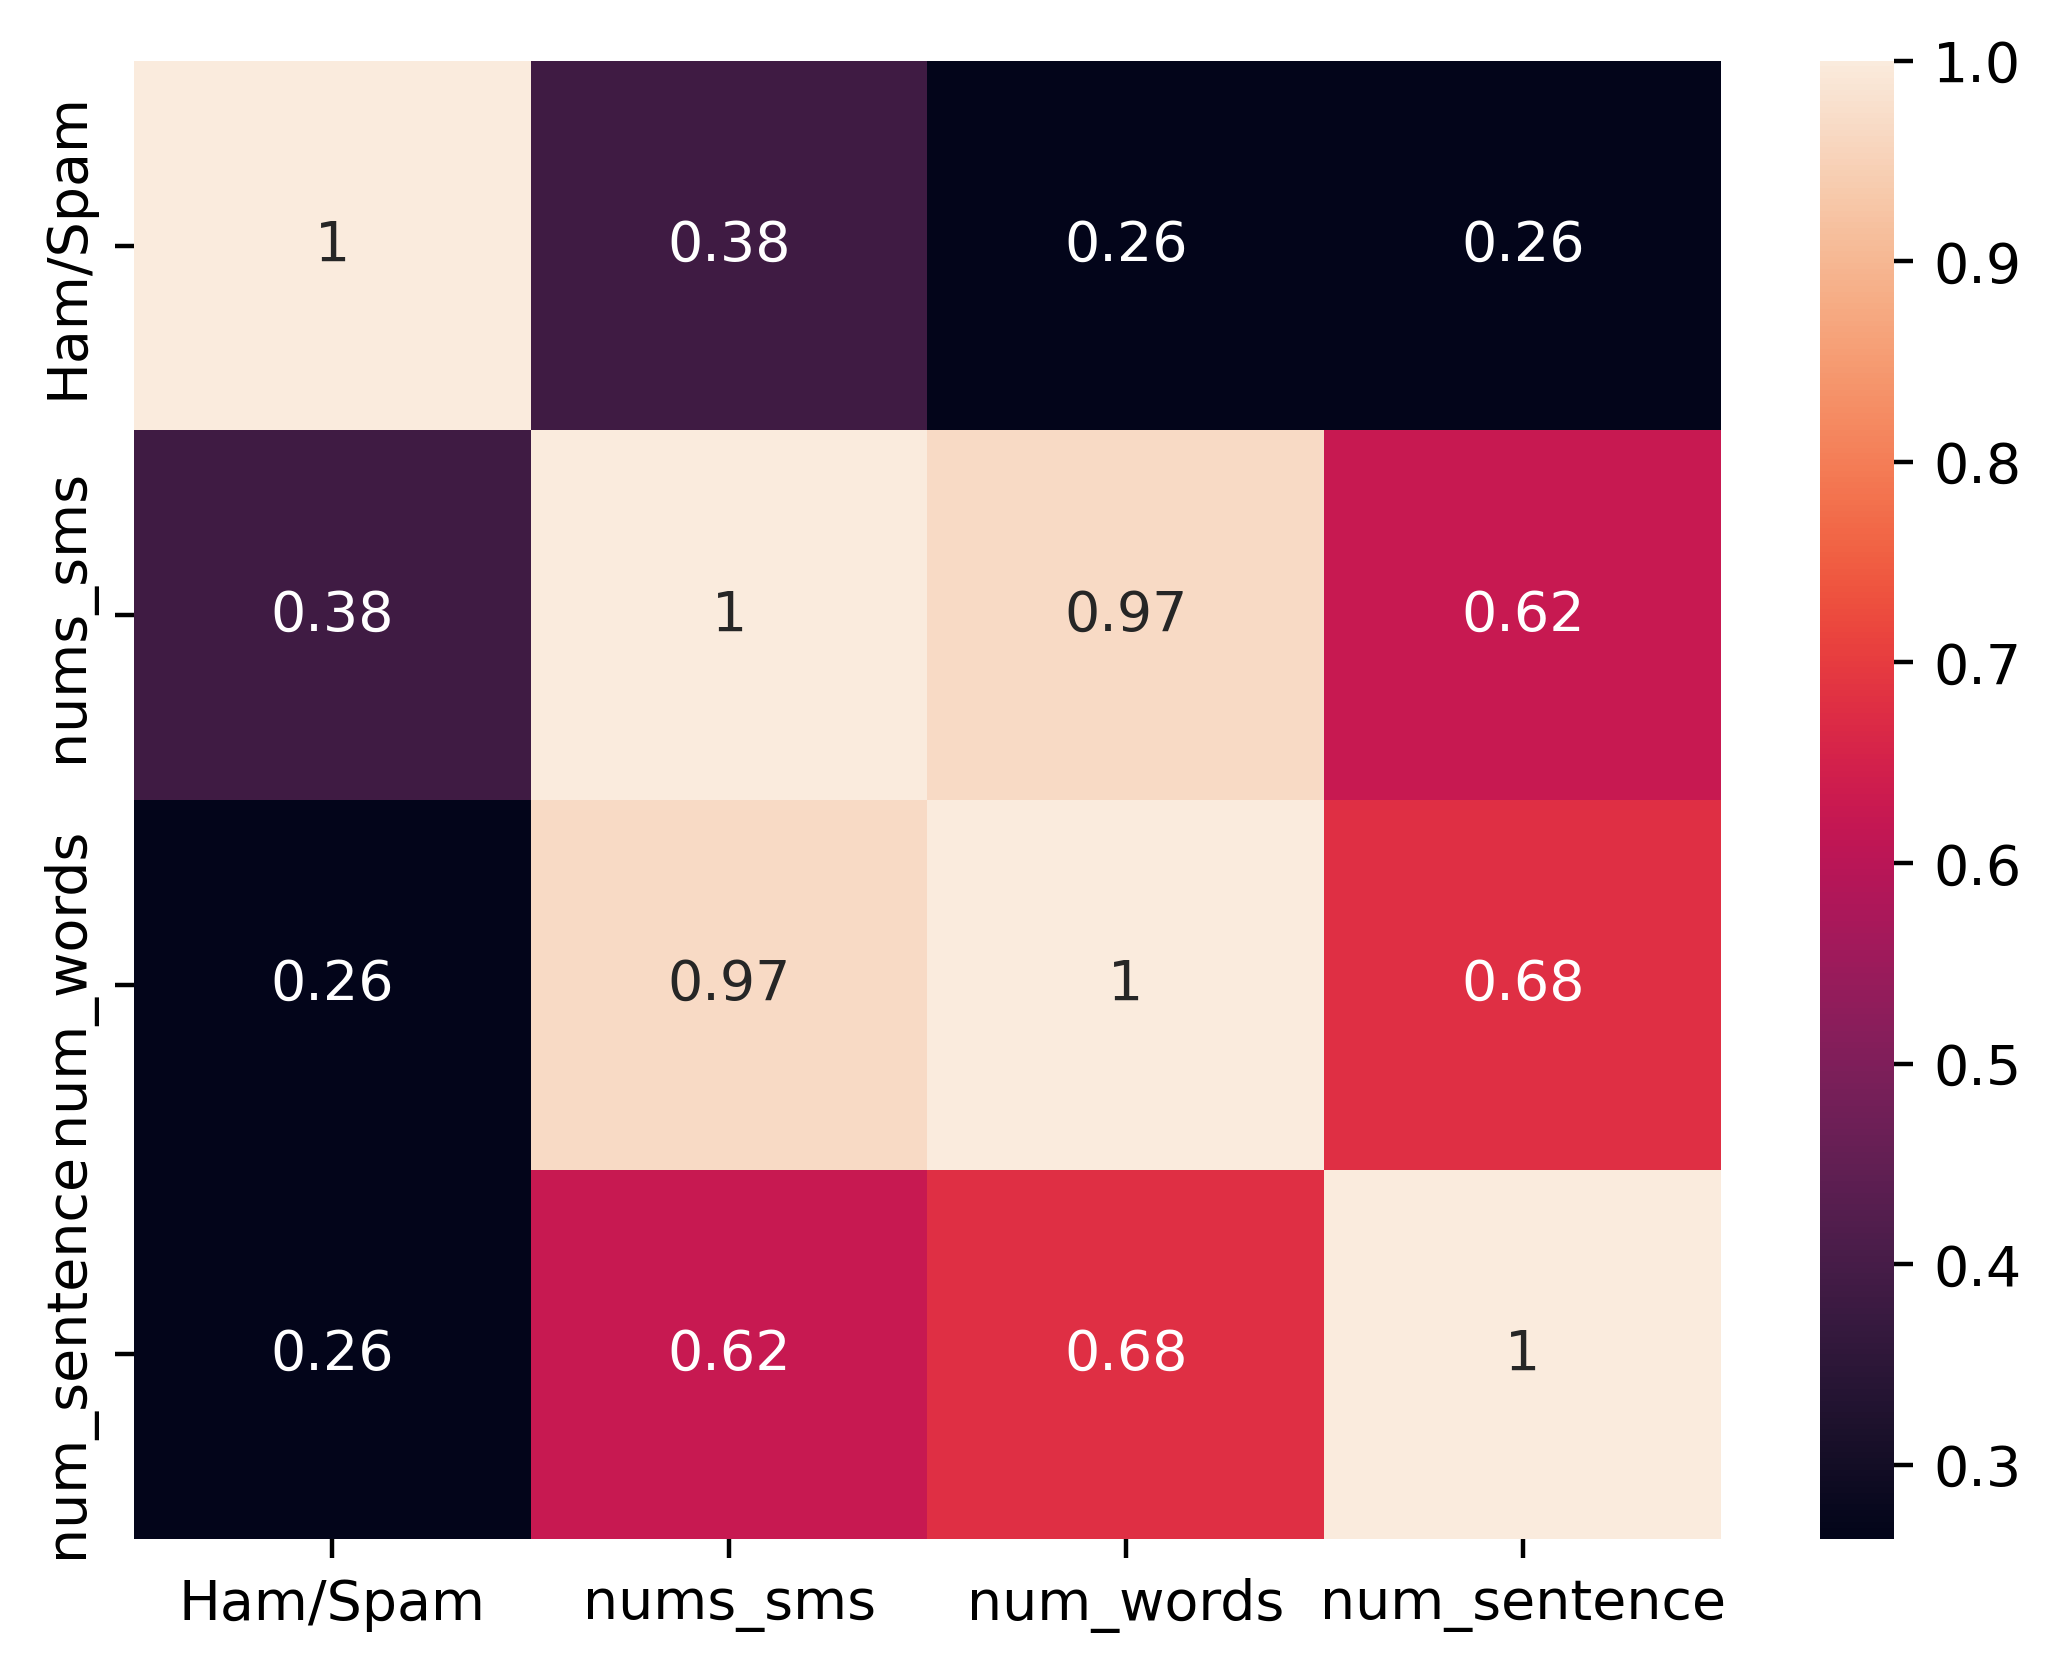

In [30]:
sns.heatmap(num_df.corr(),annot = True)

In [31]:
from nltk.corpus import stopwords
import string

In [32]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [33]:
def converter (obj):
    obj = obj.lower()
    obj = nltk.word_tokenize(obj)
    res = [word for word in obj if word.isalnum()] 
    obj = res
    res = [ i  for i in obj  if i not in stopwords.words('english') and  i not in string.punctuation]
    obj = res 
    res = [ ps.stem(i)  for i in obj ]
    return " ".join(res)

In [34]:
converter("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [35]:
df["text"] = df['sms'].apply(converter)

In [36]:
df['text'][10]

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [37]:
from wordcloud import WordCloud
wc = WordCloud(background_color = 'white')

In [38]:
spam_cloud  = wc.generate(df[df['Ham/Spam'] == 1]['text'].str.cat(sep= " "))

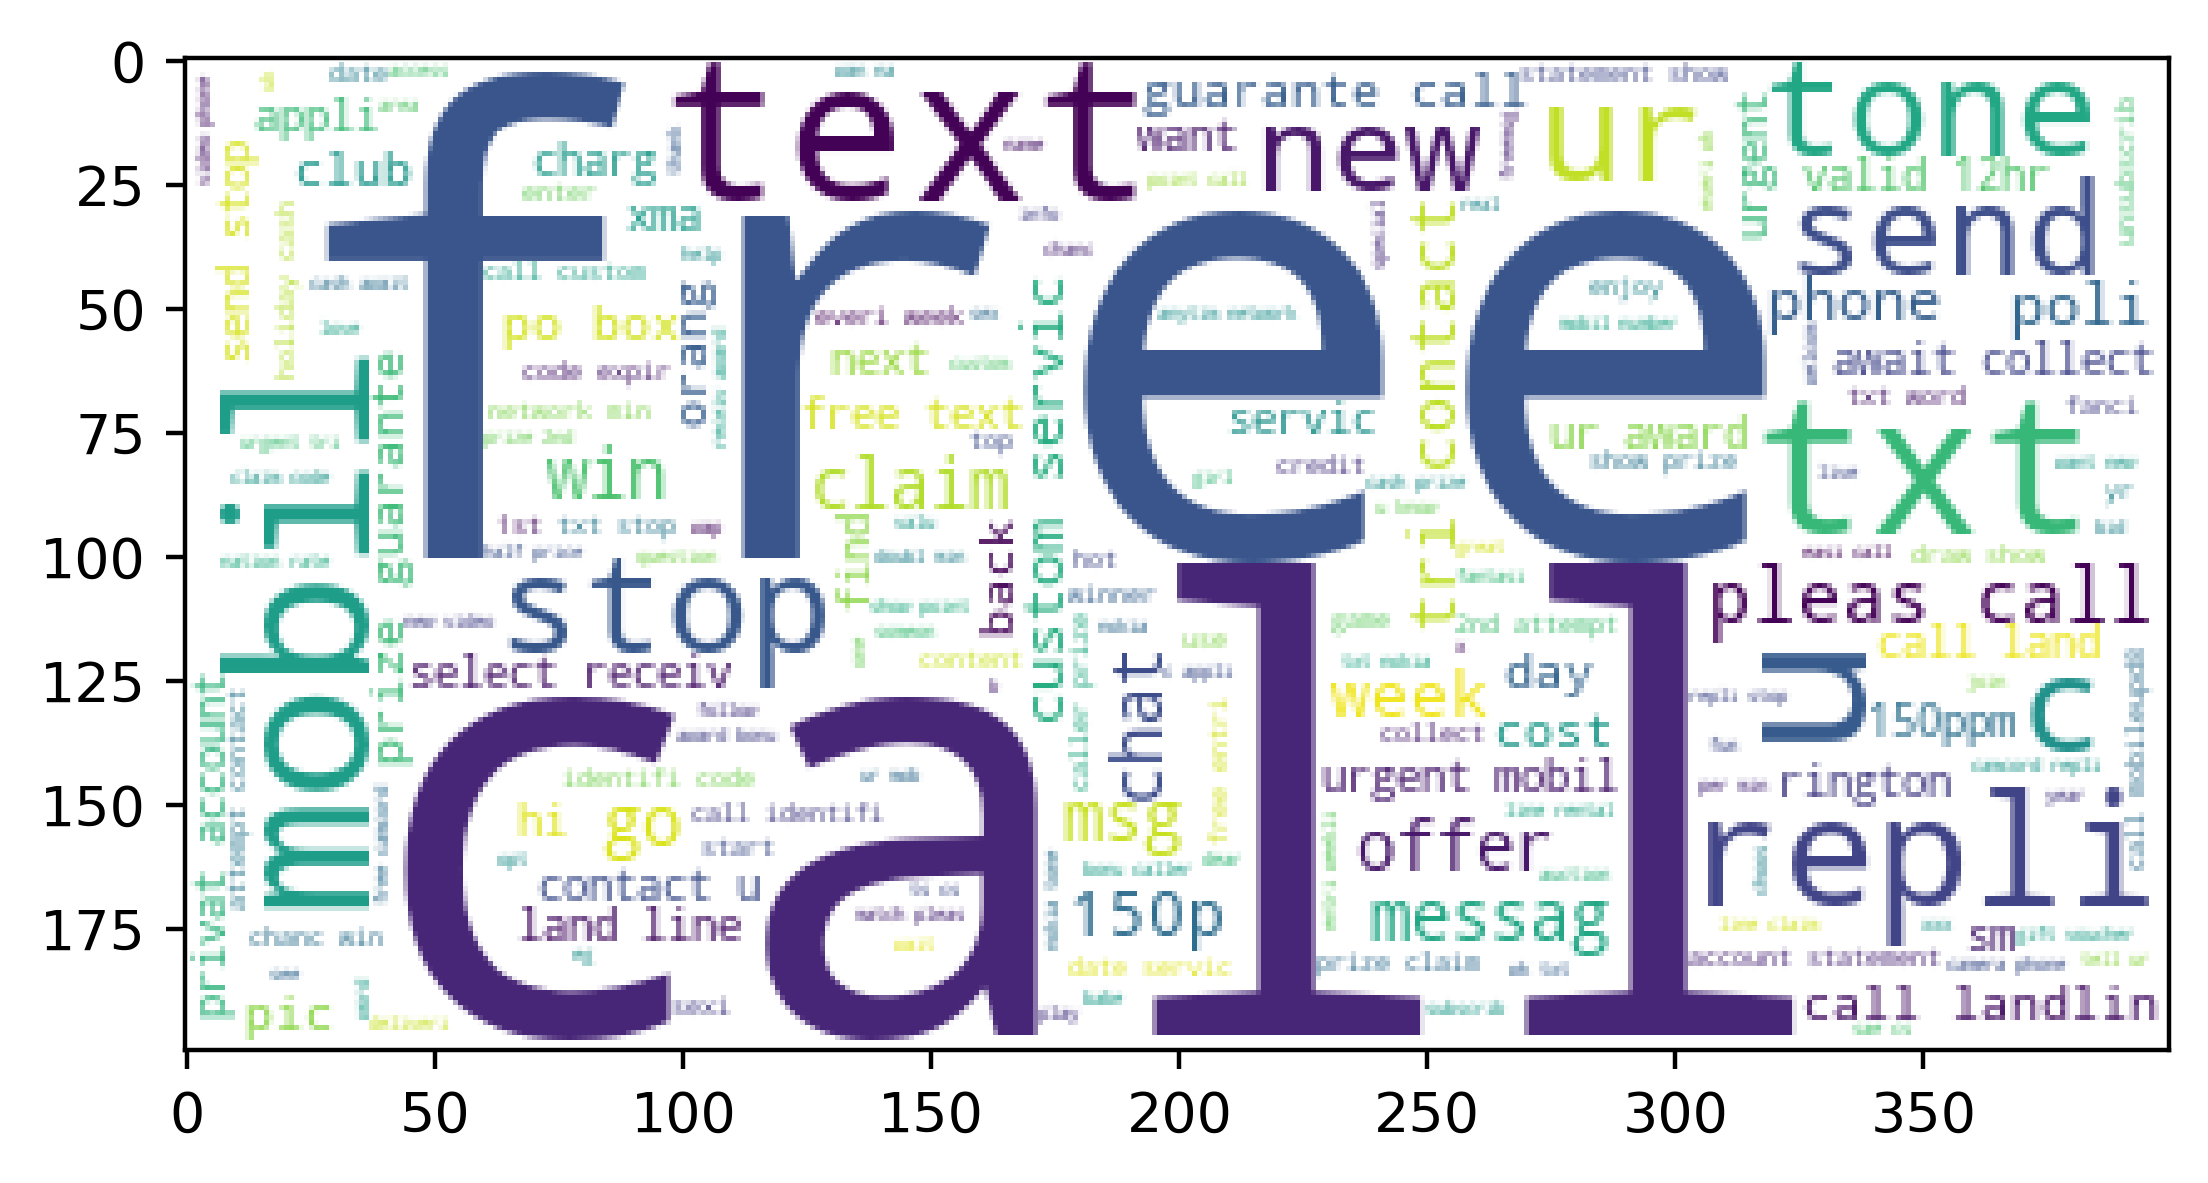

In [39]:
plt.imshow(spam_cloud)

In [40]:
Ham_cloud  = wc.generate(df[df['Ham/Spam'] == 0]['text'].str.cat(sep= " "))

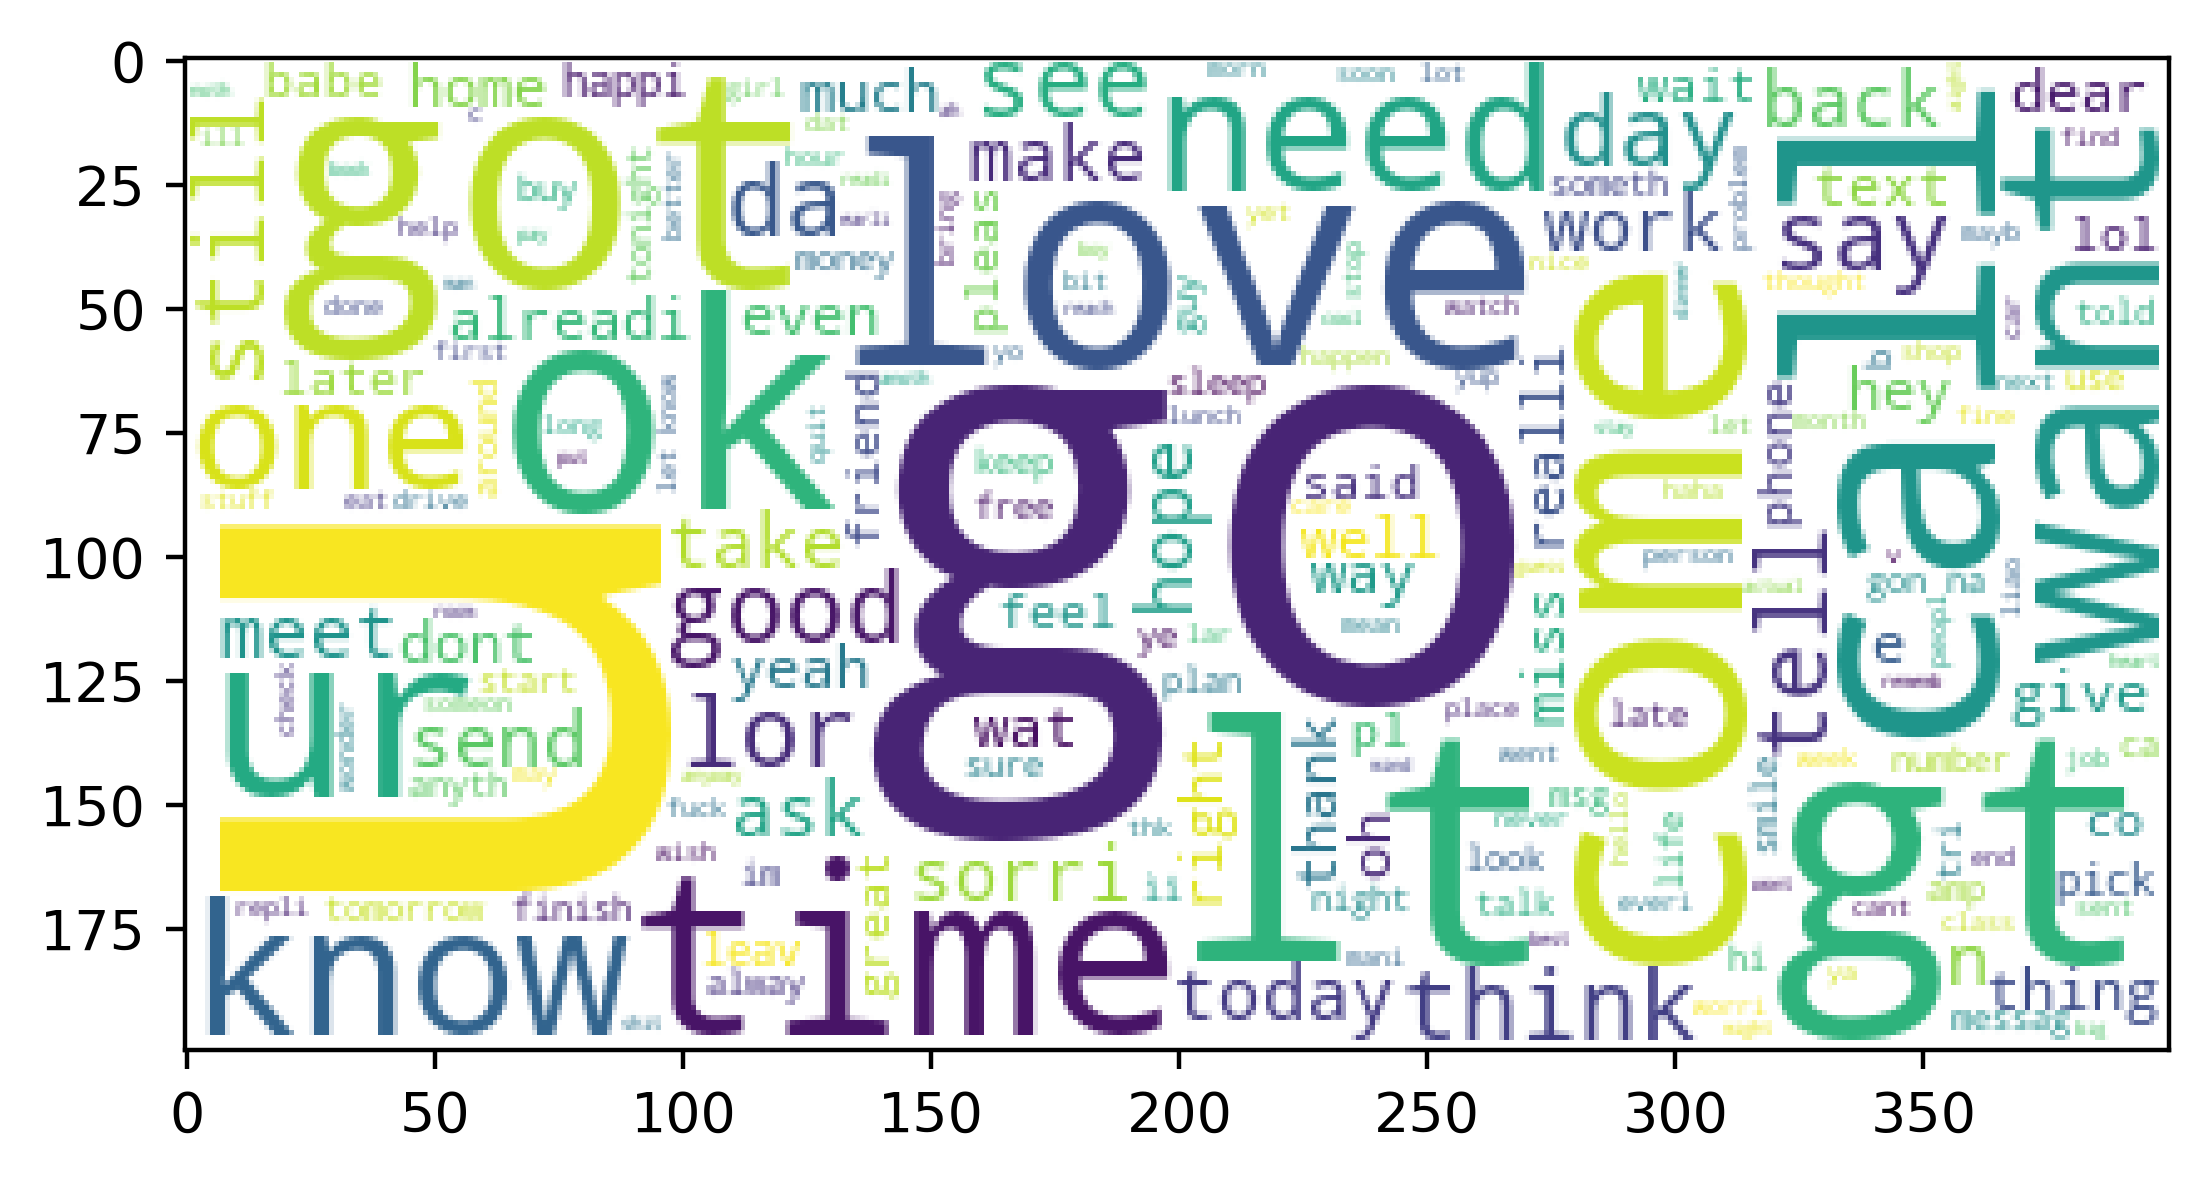

In [41]:
plt.imshow(Ham_cloud)

In [42]:
from collections import Counter

In [43]:
spam = [word  for i in df[df['Ham/Spam']==1]['text'].to_list() for word in i.split()]

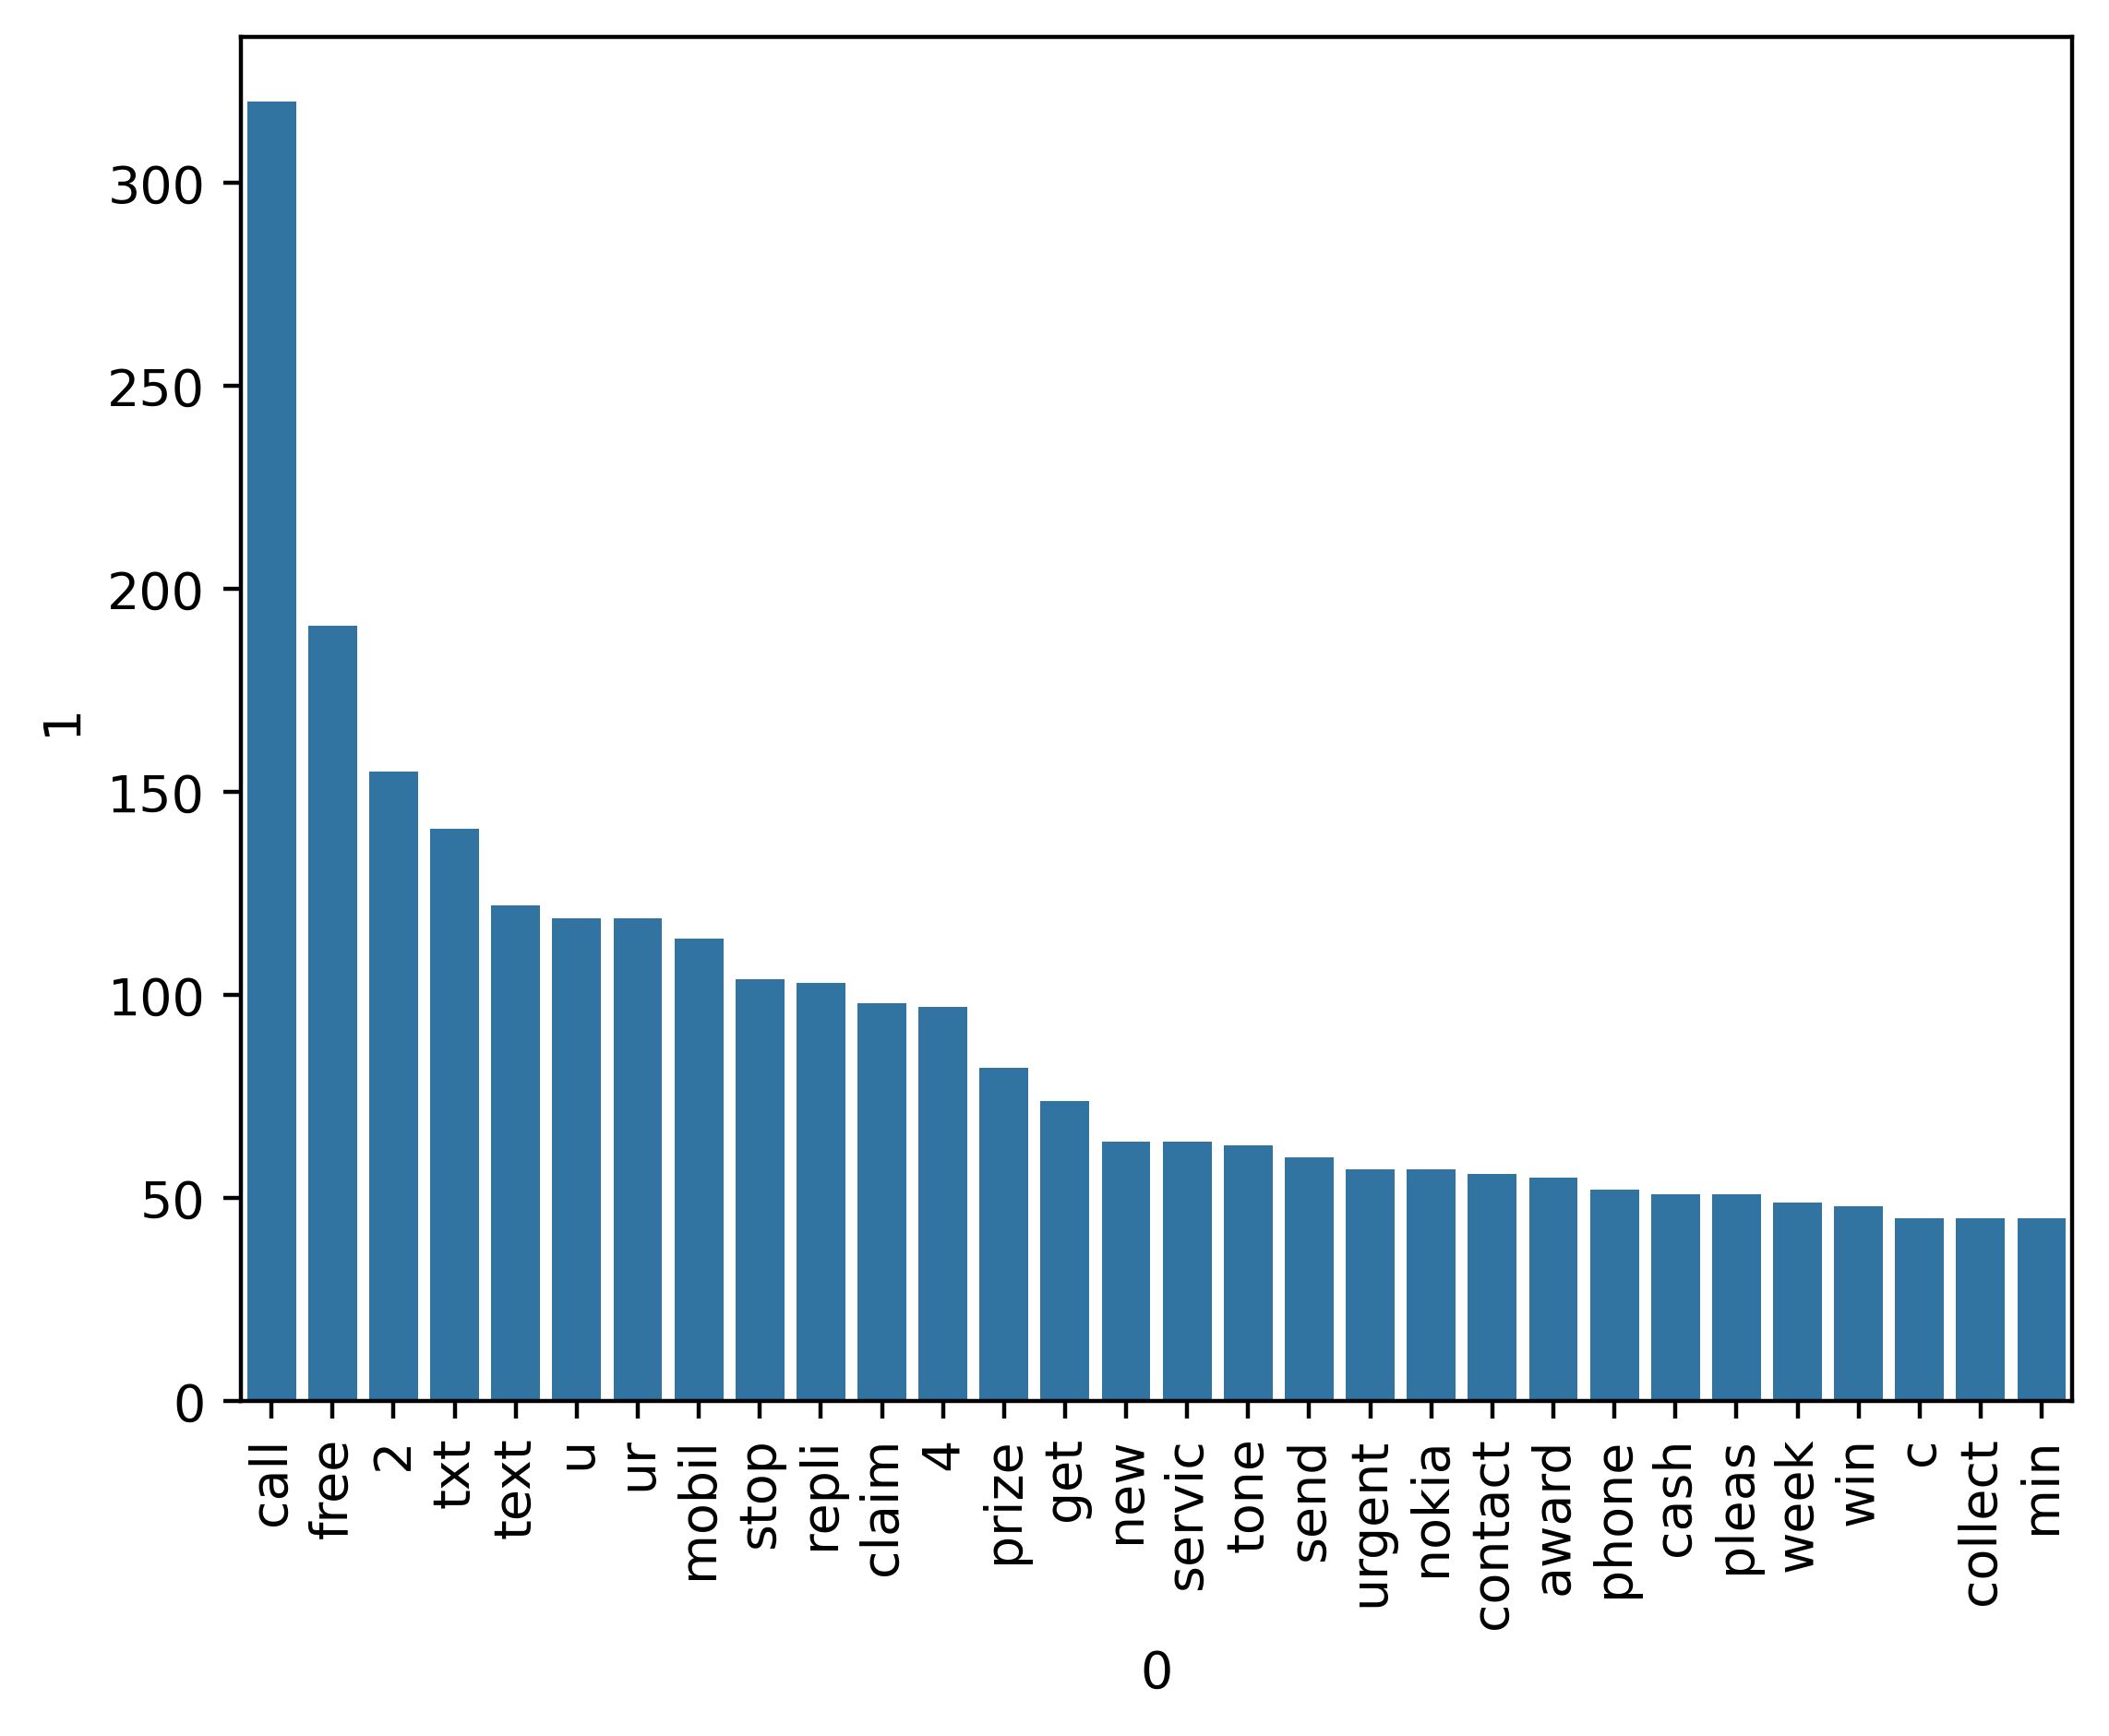

In [44]:
sns.barplot(x = pd.DataFrame(Counter(spam).most_common(30))[0], y = pd.DataFrame(Counter(spam).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [45]:
ham = [word  for i in df[df['Ham/Spam']==0]['text'].to_list() for word in i.split()]

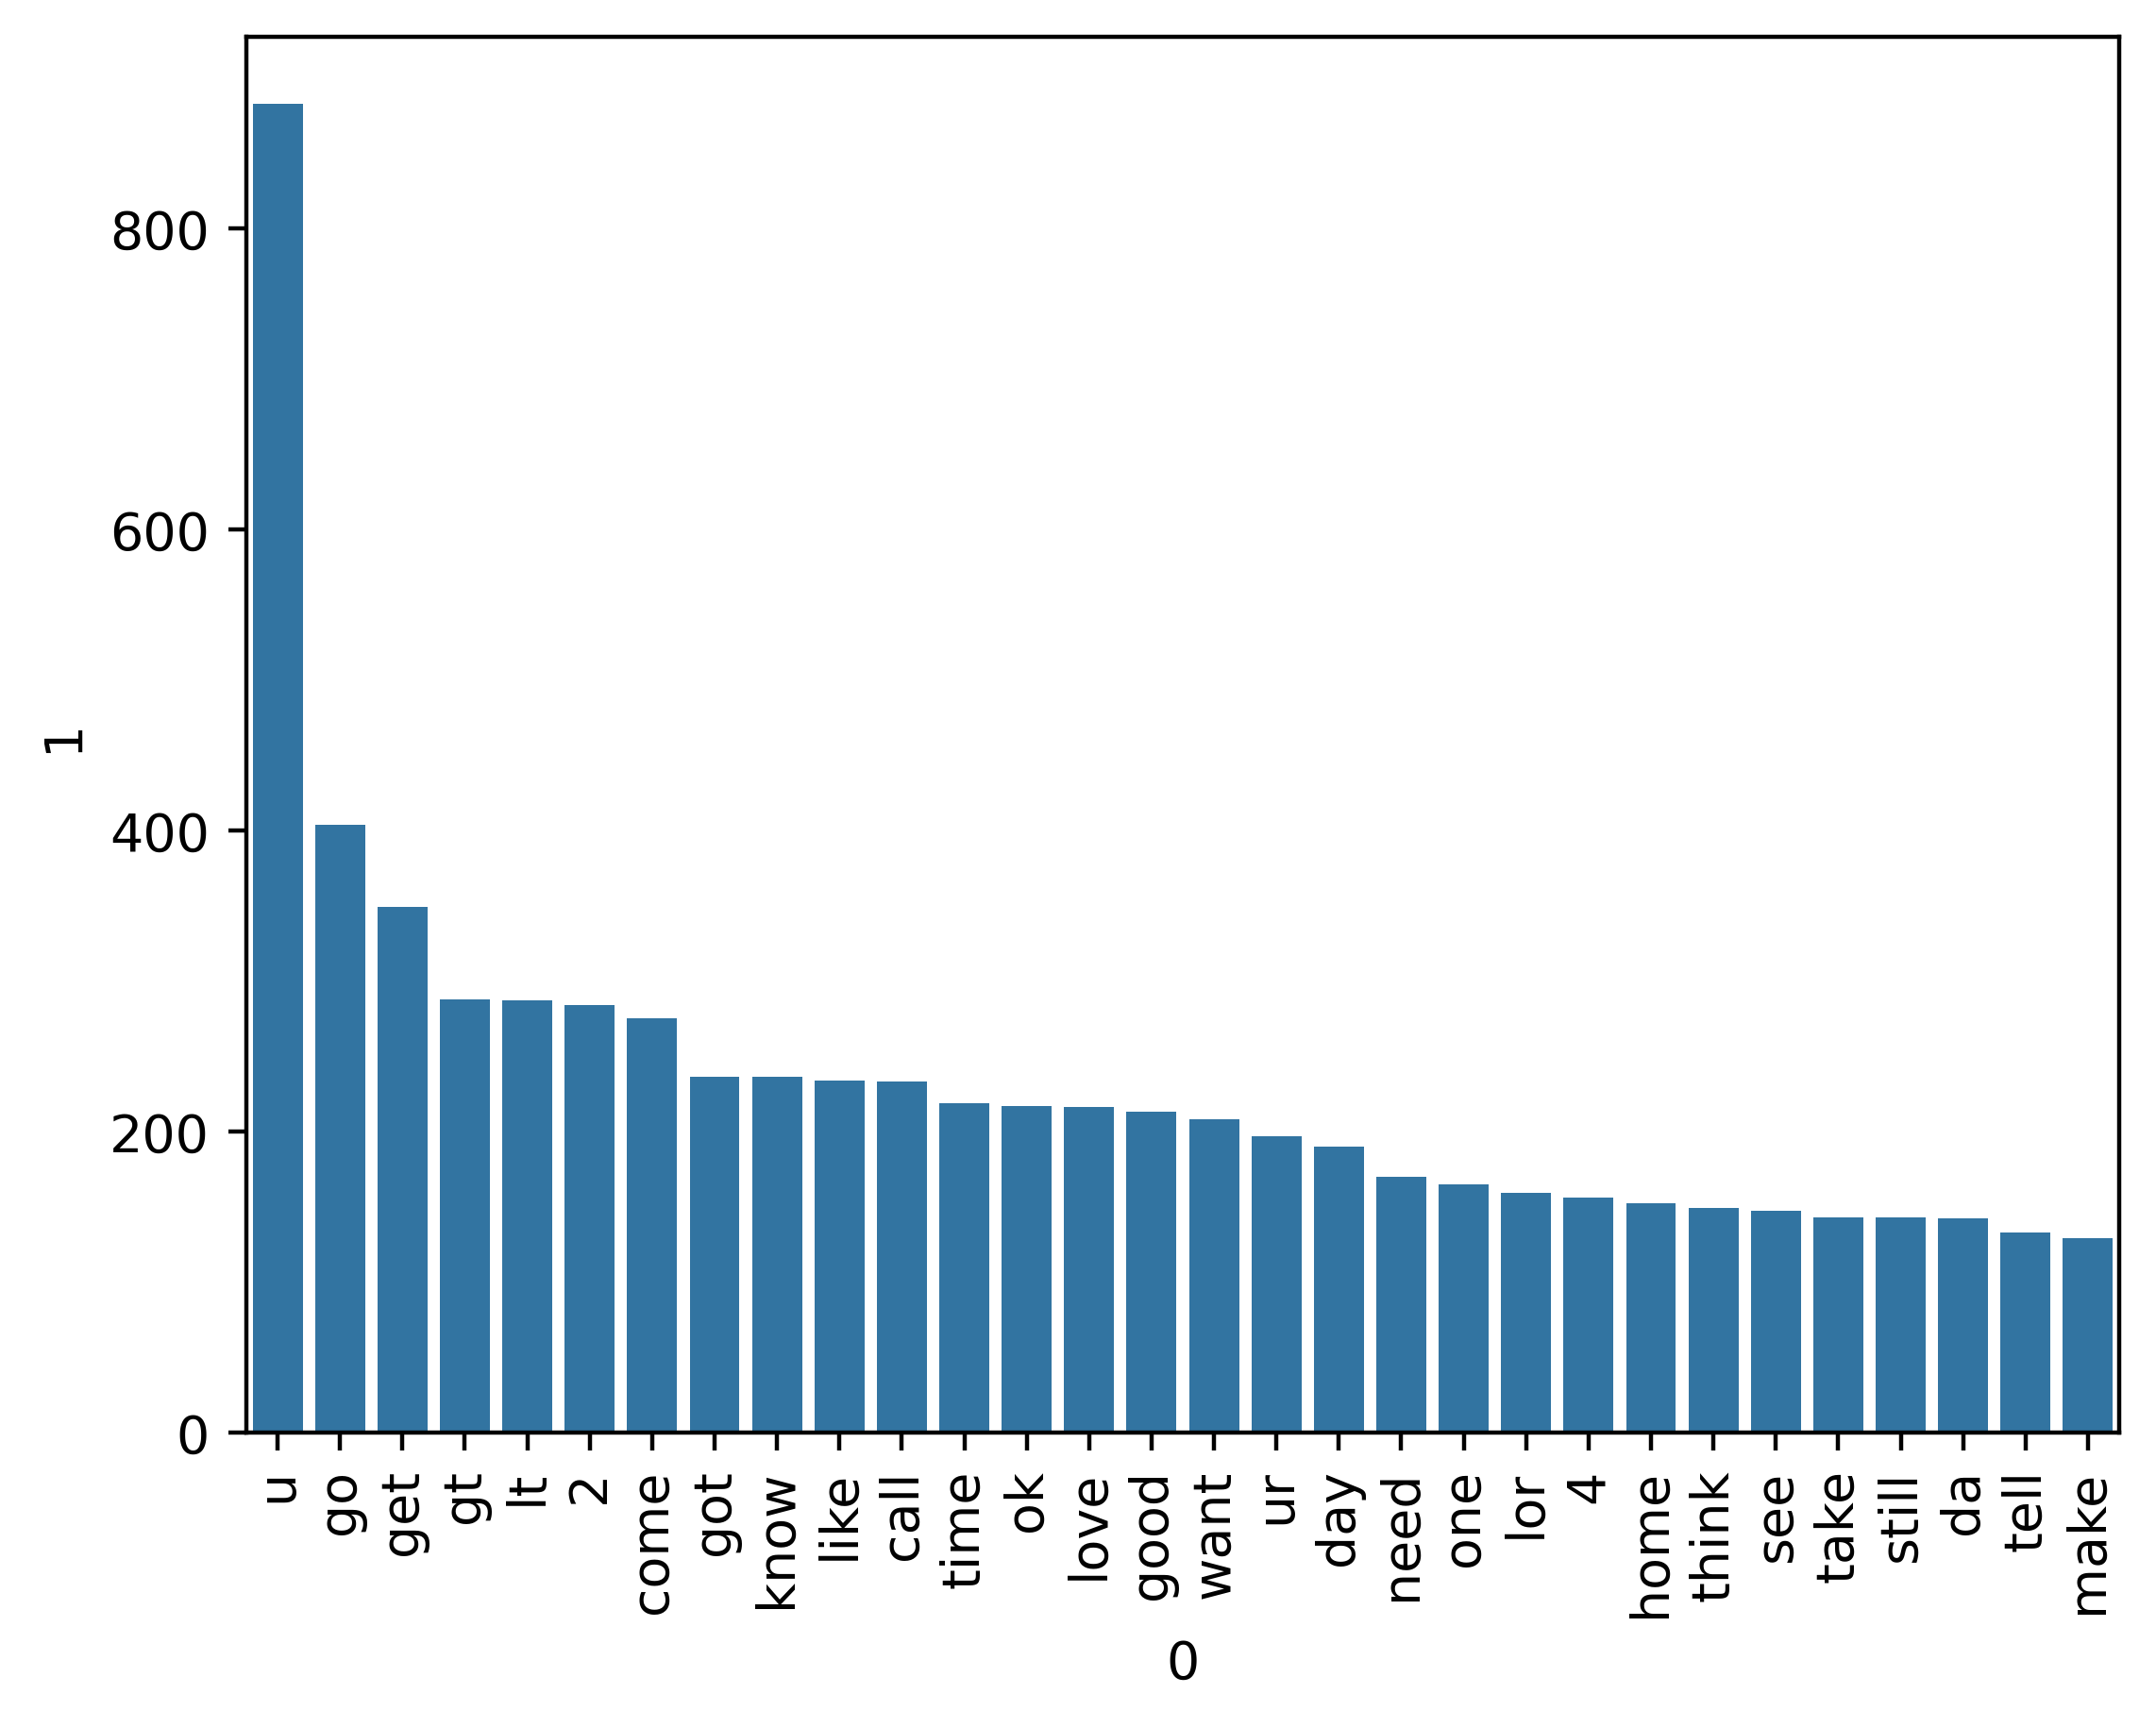

In [46]:
sns.barplot(x = pd.DataFrame(Counter(ham).most_common(30))[0], y = pd.DataFrame(Counter(ham).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

In [47]:
df.head()

,Ham/Spam,sms,nums_sms,num_words,num_sentence,text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


# Model selection begins here 

In [48]:
# since we need to convert the text into vertex form to feed into hte model
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf= TfidfVectorizer()

In [49]:
x = tfidf.fit_transform(df['text']).toarray()

In [50]:
x.shape

(5169, 6708)

In [51]:
y = df['Ham/Spam'].values

In [52]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [53]:
from sklearn.model_selection import train_test_split

We are feeding 20% of data to the test

In [54]:
x_train, x_test, y_train,y_test = train_test_split(x,y,test_size =0.2, random_state = 2)

In [55]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [56]:
gnb = GaussianNB ()
mnb = MultinomialNB ()
bnb = BernoulliNB ()

Training starts here

In [57]:
gnb.fit(x_train,y_train)
y_prediction = gnb.predict(x_test)
print(accuracy_score(y_test, y_prediction))
print(confusion_matrix(y_test, y_prediction))
print(precision_score(y_test, y_prediction))

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


In [58]:
mnb.fit(x_train,y_train)
y_prediction2 = mnb.predict(x_test)
print(accuracy_score(y_test, y_prediction2))
print(confusion_matrix(y_test, y_prediction2))
print(precision_score(y_test, y_prediction2))

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [59]:
bnb.fit(x_train,y_train)
y_prediction3 = bnb.predict(x_test)
print(accuracy_score(y_test, y_prediction3))
print(confusion_matrix(y_test, y_prediction3))
print(precision_score(y_test, y_prediction3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


# we are taking the tfidf - mnb model for now

In [1]:
# let try with other machine learning models to get the best one out

from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

: 

In [61]:
svc = SVC(kernel = 'sigmoid',gamma = 1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression(solver = 'liblinear' , penalty ='l1')
rfc = RandomForestClassifier(n_estimators = 50 , random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50 , random_state = 2)
bc  = BaggingClassifier(n_estimators = 50 , random_state = 2)
etc = ExtraTreesClassifier(n_estimators = 50 , random_state = 2)
gbdt = GradientBoostingClassifier(n_estimators = 50 , random_state = 2)
xgb = XGBClassifier(n_estimators = 50 , random_state = 2)

In [62]:
models = {
    'SVC' : svc,
     'KN' : knc,
     'NB' : mnb,
     "DT" : dtc,
     "LR" : lrc,
     'RF' : rfc,
     'AB' : abc,
     'BC' : bc,
     'ETC': etc,
    'GBDT': gbdt,
     'XGB': xgb
}

In [63]:
def model_trainer(models, x_train,y_train,x_test,y_test):
    models.fit(x_train,y_train)
    y_prediction = models.predict(x_test)
    accuracy = accuracy_score(y_test,y_prediction)
    precision = precision_score(y_test,y_prediction)
    return accuracy,precision

In [64]:
model_trainer(lrc, x_train,y_train,x_test,y_test)

(0.9516441005802708, 0.94)

In [73]:
accuracy_scores = []
precision_scores = []

for name , model in models.items():
    current_accuracy,current_precision = model_trainer(model,x_train,y_train,x_test,y_test)
    print('For ', name)
    print('Accuracy - ' , current_accuracy)
    print('Precision - ' , current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

For  SVC
Accuracy -  0.9729206963249516
Precision -  0.9741379310344828
For  KN
Accuracy -  0.9003868471953579
Precision -  1.0
For  NB
Accuracy -  0.9593810444874274
Precision -  1.0
For  DT
Accuracy -  0.9352030947775629
Precision -  0.8380952380952381
For  LR
Accuracy -  0.9516441005802708
Precision -  0.94
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AB
Accuracy -  0.9245647969052224
Precision -  0.8409090909090909
For  BC
Accuracy -  0.9584139264990329
Precision -  0.8625954198473282
For  ETC
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  GBDT
Accuracy -  0.9526112185686654
Precision -  0.9238095238095239
For  XGB
Accuracy -  0.9729206963249516
Precision -  0.9435483870967742


In [74]:
preformance_df = pd.DataFrame({'Algorithm' :models.keys(), 'Accuracy' : accuracy_scores, 'Precision' : precision_scores}).sort_values('Precision',ascending = False)

In [76]:
preformance_df

,Algorithm,Accuracy,Precision
1,KN,0.900387,1.000000
2,NB,0.959381,1.000000
5,RF,0.971954,1.000000
8,ETC,0.972921,0.982456
0,SVC,0.972921,0.974138
10,XGB,0.972921,0.943548
4,LR,0.951644,0.940000
9,GBDT,0.952611,0.923810
7,BC,0.958414,0.862595
6,AB,0.924565,0.840909


In [77]:
melted_df = pd.melt(preformance_df, id_vars='Algorithm')

In [78]:
melted_df

,Algorithm,variable,value
0,KN,Accuracy,0.900387
1,NB,Accuracy,0.959381
2,RF,Accuracy,0.971954
3,ETC,Accuracy,0.972921
4,SVC,Accuracy,0.972921
5,XGB,Accuracy,0.972921
6,LR,Accuracy,0.951644
7,GBDT,Accuracy,0.952611
8,BC,Accuracy,0.958414
9,AB,Accuracy,0.924565


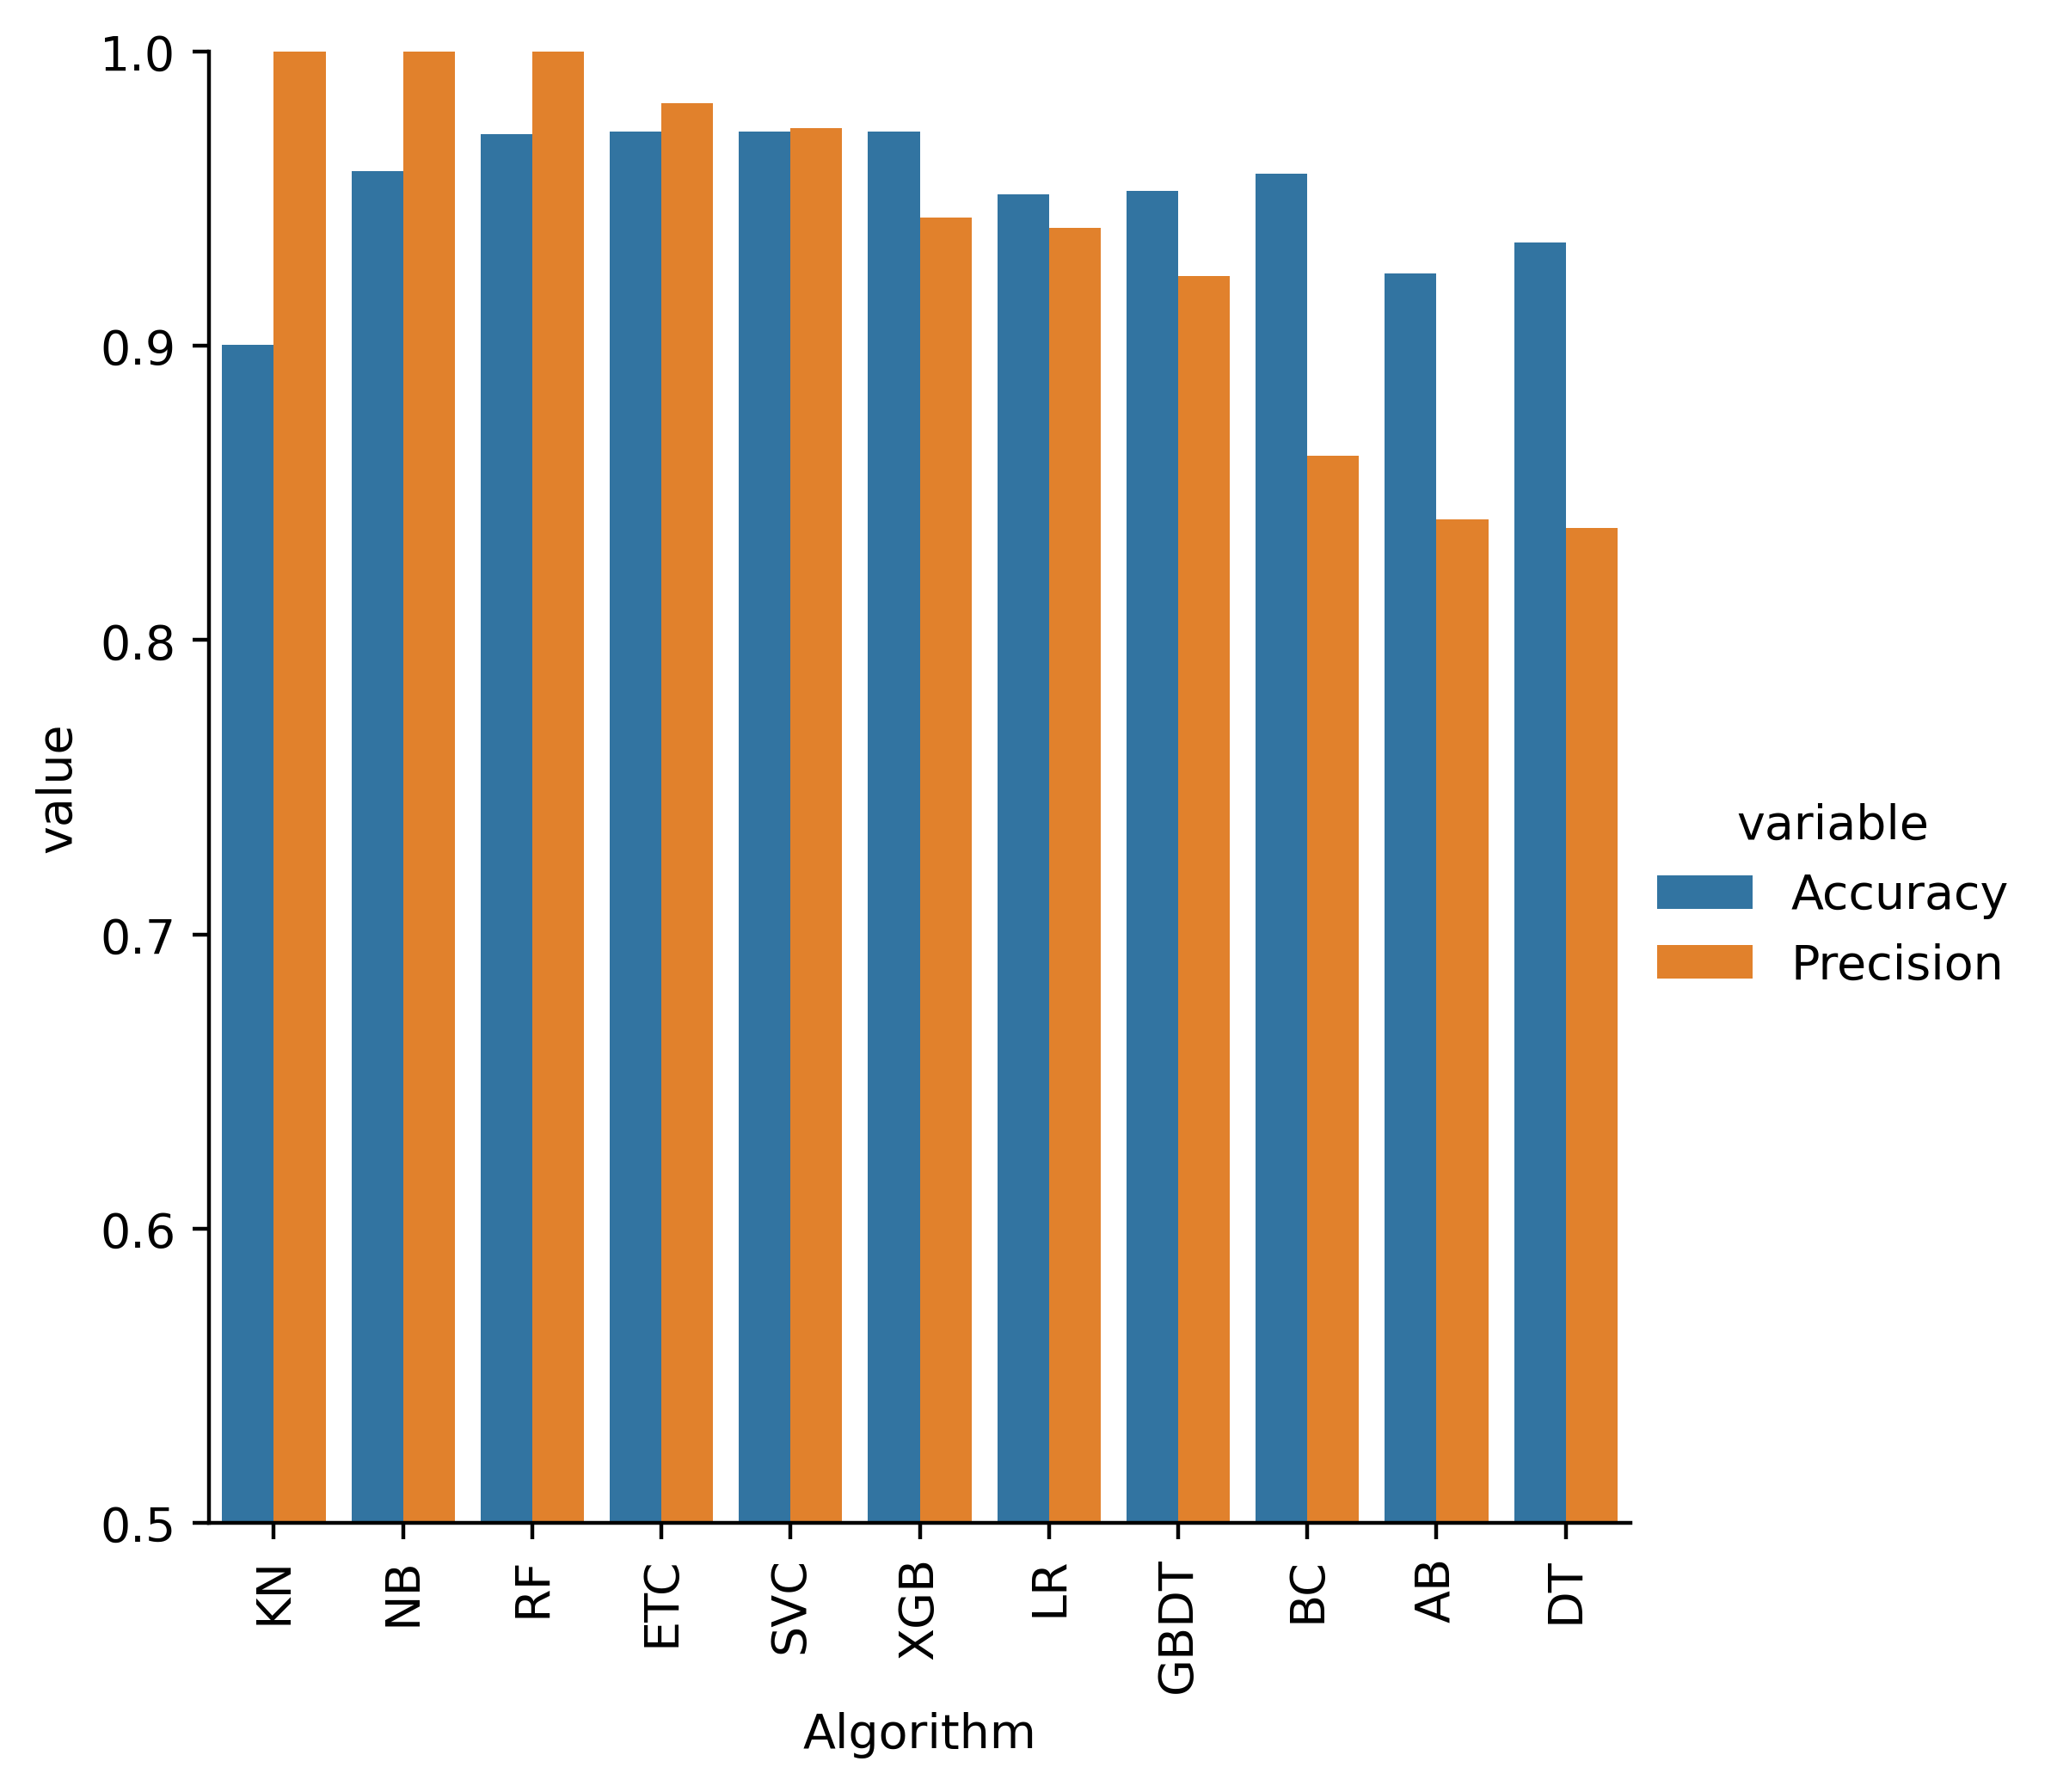

In [79]:
sns.catplot(x='Algorithm' , y = 'value', hue='variable', data = melted_df, kind ='bar' , height = 5)
plt.ylim(0.5,1.0)
plt.xticks(rotation = 'vertical')
plt.show()